# Zero-Shot Cross-Condition Transfer Experiment — Results

This notebook reports the authoritative **v2** cross-condition transfer results from the versioned local artifact layout.


### Cell 1 — Imports, Configuration, and Data Loading

Loads `experiments/results/v2/cross_condition_results_v2.json` together with the three authoritative within-condition v2 result files. Builds `WITHIN_F1_PER_CLF`, a per-classifier within-condition lookup used to compute ΔF1 = within F1 − cross F1 for every direction/classifier pair.


In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

RESULTS_DIR = Path('../experiments/results/v2')
FIGURES_PDF = Path('../report/figures/v2/pdf')
FIGURES_PNG = Path('../report/figures/v2/png')
FIGURES_PDF.mkdir(parents=True, exist_ok=True)
FIGURES_PNG.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / 'cross_condition_results_v2.json') as f:
    cc = json.load(f)
with open(RESULTS_DIR / 'pd_results_v2.json') as f:
    pd_res = json.load(f)
with open(RESULTS_DIR / 'hd_results_v2.json') as f:
    hd_res = json.load(f)
with open(RESULTS_DIR / 'als_results_v2.json') as f:
    als_res = json.load(f)

DIRECTIONS = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABELS = ['PD→HD', 'HD→PD', 'PD→ALS', 'ALS→PD', 'HD→ALS', 'ALS→HD']
CLF_NAMES = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']

BEST_CLF = {
    'pd': max(CLF_NAMES, key=lambda c: pd_res['classifiers'][c]['f1_macro']),
    'hd': max(CLF_NAMES, key=lambda c: hd_res['classifiers'][c]['f1_macro']),
    'als': max(CLF_NAMES, key=lambda c: als_res['classifiers'][c]['f1_macro']),
}

WITHIN_F1_PER_CLF = {
    'pd': {clf: pd_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
    'hd': {clf: hd_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
    'als': {clf: als_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
}

WITHIN_F1 = {
    'pd': pd_res['classifiers'][BEST_CLF['pd']]['f1_macro'],
    'hd': hd_res['classifiers'][BEST_CLF['hd']]['f1_macro'],
    'als': als_res['classifiers'][BEST_CLF['als']]['f1_macro'],
}

print('Loaded authoritative v2 transfer results.')
print(f'Figures will be saved to: {FIGURES_PDF.parent.resolve()}')
print(f'Best classifier per source condition: {BEST_CLF}')
assert set(cc.keys()) == set(DIRECTIONS), f'Direction mismatch: {set(cc.keys())}'


Loaded authoritative v2 transfer results.
Figures will be saved to: /home/ahmad_shahmeer/ML_Research/gait-transfer-ndd/report/figures/v2
Best classifier per source condition: {'pd': 'dt', 'hd': 'xgb', 'als': 'knn'}


### Cell 2 — Cross-Condition Degradation Table

Builds the primary result of this study: a 42-row table (7 classifiers × 6 directions) with cross-condition F1, within-condition F1, ΔF1, both bootstrap 95% CIs, and permutation p-values.

**What to look for:** `PD→HD` is still the only direction with a **negative mean ΔF1** (`-0.0171`), but it is **not** negative for all 7 classifiers: 5 of 7 classifiers improve (RF, SVM, QDA, XGBoost, LightGBM), while KNN (`+0.0565`) and DT (`+0.0355`) remain slightly positive. The largest **mean** degradation is `HD→ALS` (`+0.1565`), followed by `HD→PD` (`+0.1317`). At the classifier level, the biggest positive gaps include RF on `HD→ALS` (`+0.2742`) and KNN on `ALS→HD` (`+0.2022`). All 42 permutation p-values in the stored result JSON round to `0.0000`, confirming above-chance performance in every direction. The table is split into two matplotlib figures for readability; row colour coding: red = ΔF1 > 0.20 (severe degradation), orange = 0.05–0.20, blue = ΔF1 < −0.01 (improvement).


,direction,clf,cross_f1,within_f1,delta_f1,stride_ci_lower,stride_ci_upper,subj_ci_lower,subj_ci_upper,p_value
0,pd_to_hd,rf,0.8682,0.7730,-0.0952,0.8590,0.8765,0.7094,0.9856,0.0000
1,pd_to_hd,knn,0.7019,0.7584,+0.0565,0.6902,0.7132,0.5442,0.8248,0.0000
2,pd_to_hd,svm,0.8192,0.7353,-0.0839,0.8074,0.8293,0.6353,0.9425,0.0000
3,pd_to_hd,dt,0.8313,0.8668,+0.0355,0.8212,0.8404,0.6467,0.9623,0.0000
4,pd_to_hd,qda,0.7438,0.7391,-0.0047,0.7327,0.7542,0.5709,0.8707,0.0000
5,pd_to_hd,xgb,0.7615,0.7351,-0.0265,0.7491,0.7728,0.5233,0.9276,0.0000
6,pd_to_hd,lgbm,0.8200,0.8186,-0.0014,0.8098,0.8307,0.6103,0.9600,0.0000
7,hd_to_pd,rf,0.7252,0.9530,+0.2278,0.7135,0.7366,0.5000,0.8983,0.0000
8,hd_to_pd,knn,0.6974,0.8046,+0.1072,0.6853,0.7097,0.5066,0.8388,0.0000
9,hd_to_pd,svm,0.7112,0.8720,+0.1608,0.6987,0.7233,0.4981,0.8745,0.0000


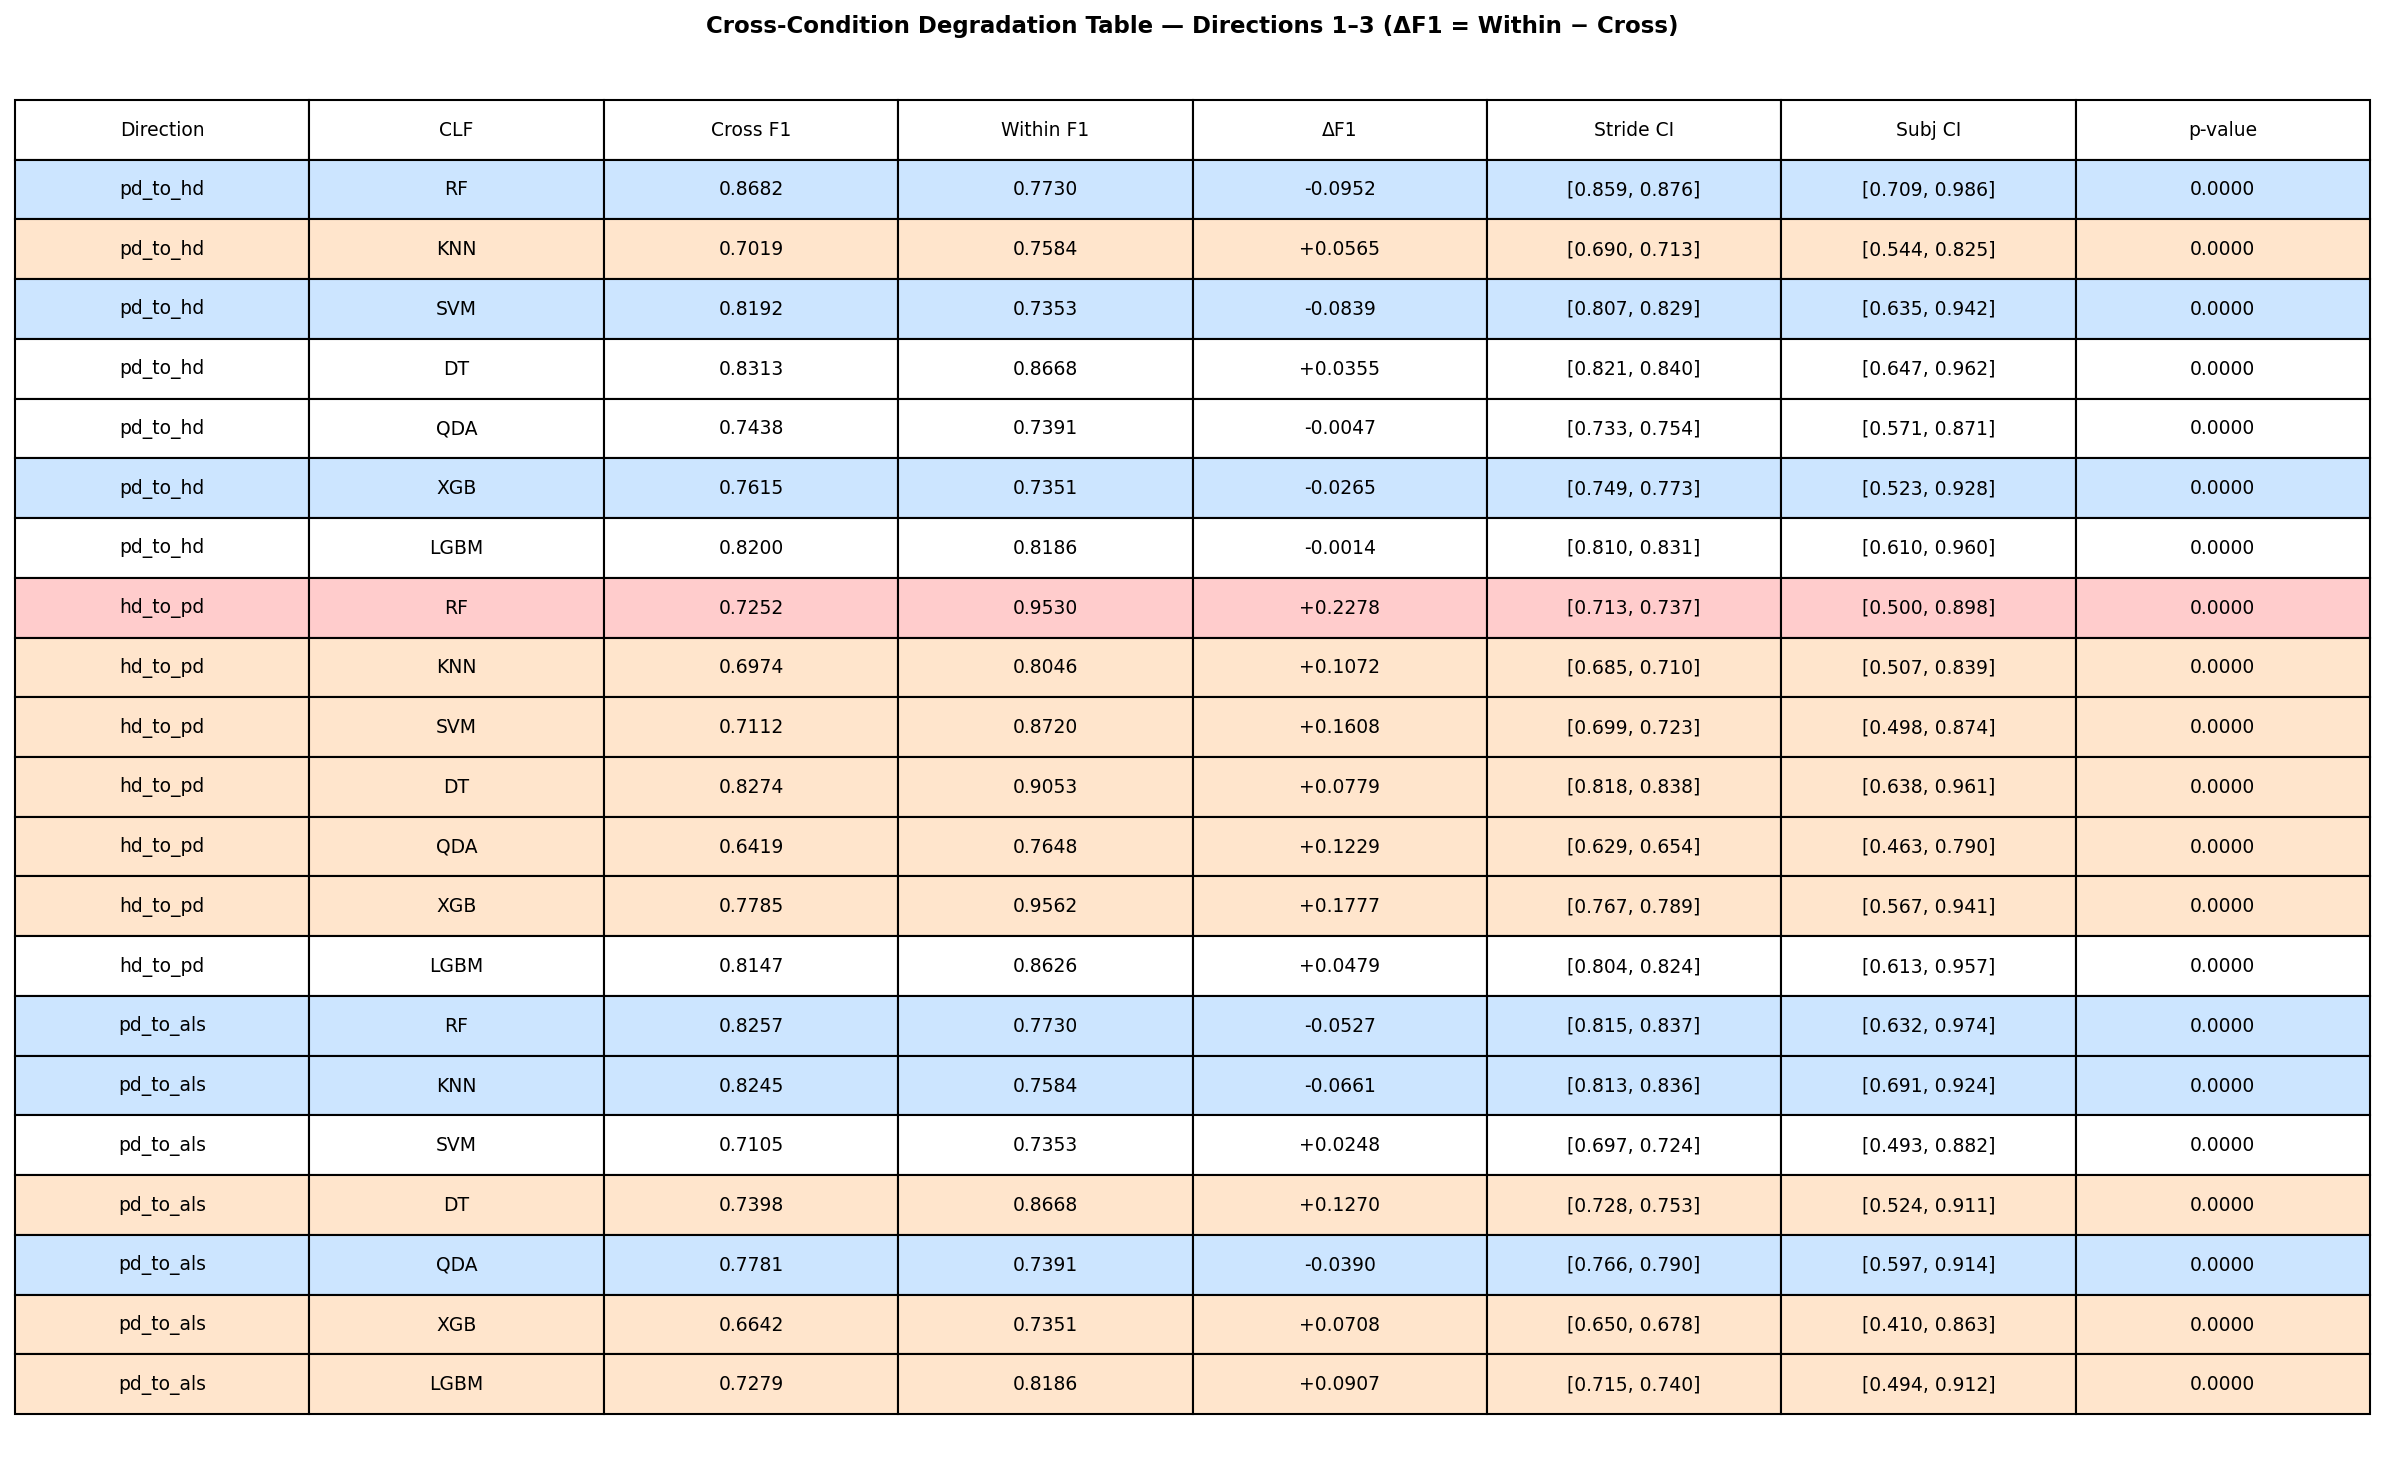

Saved: degradation_table_part1.pdf / .png


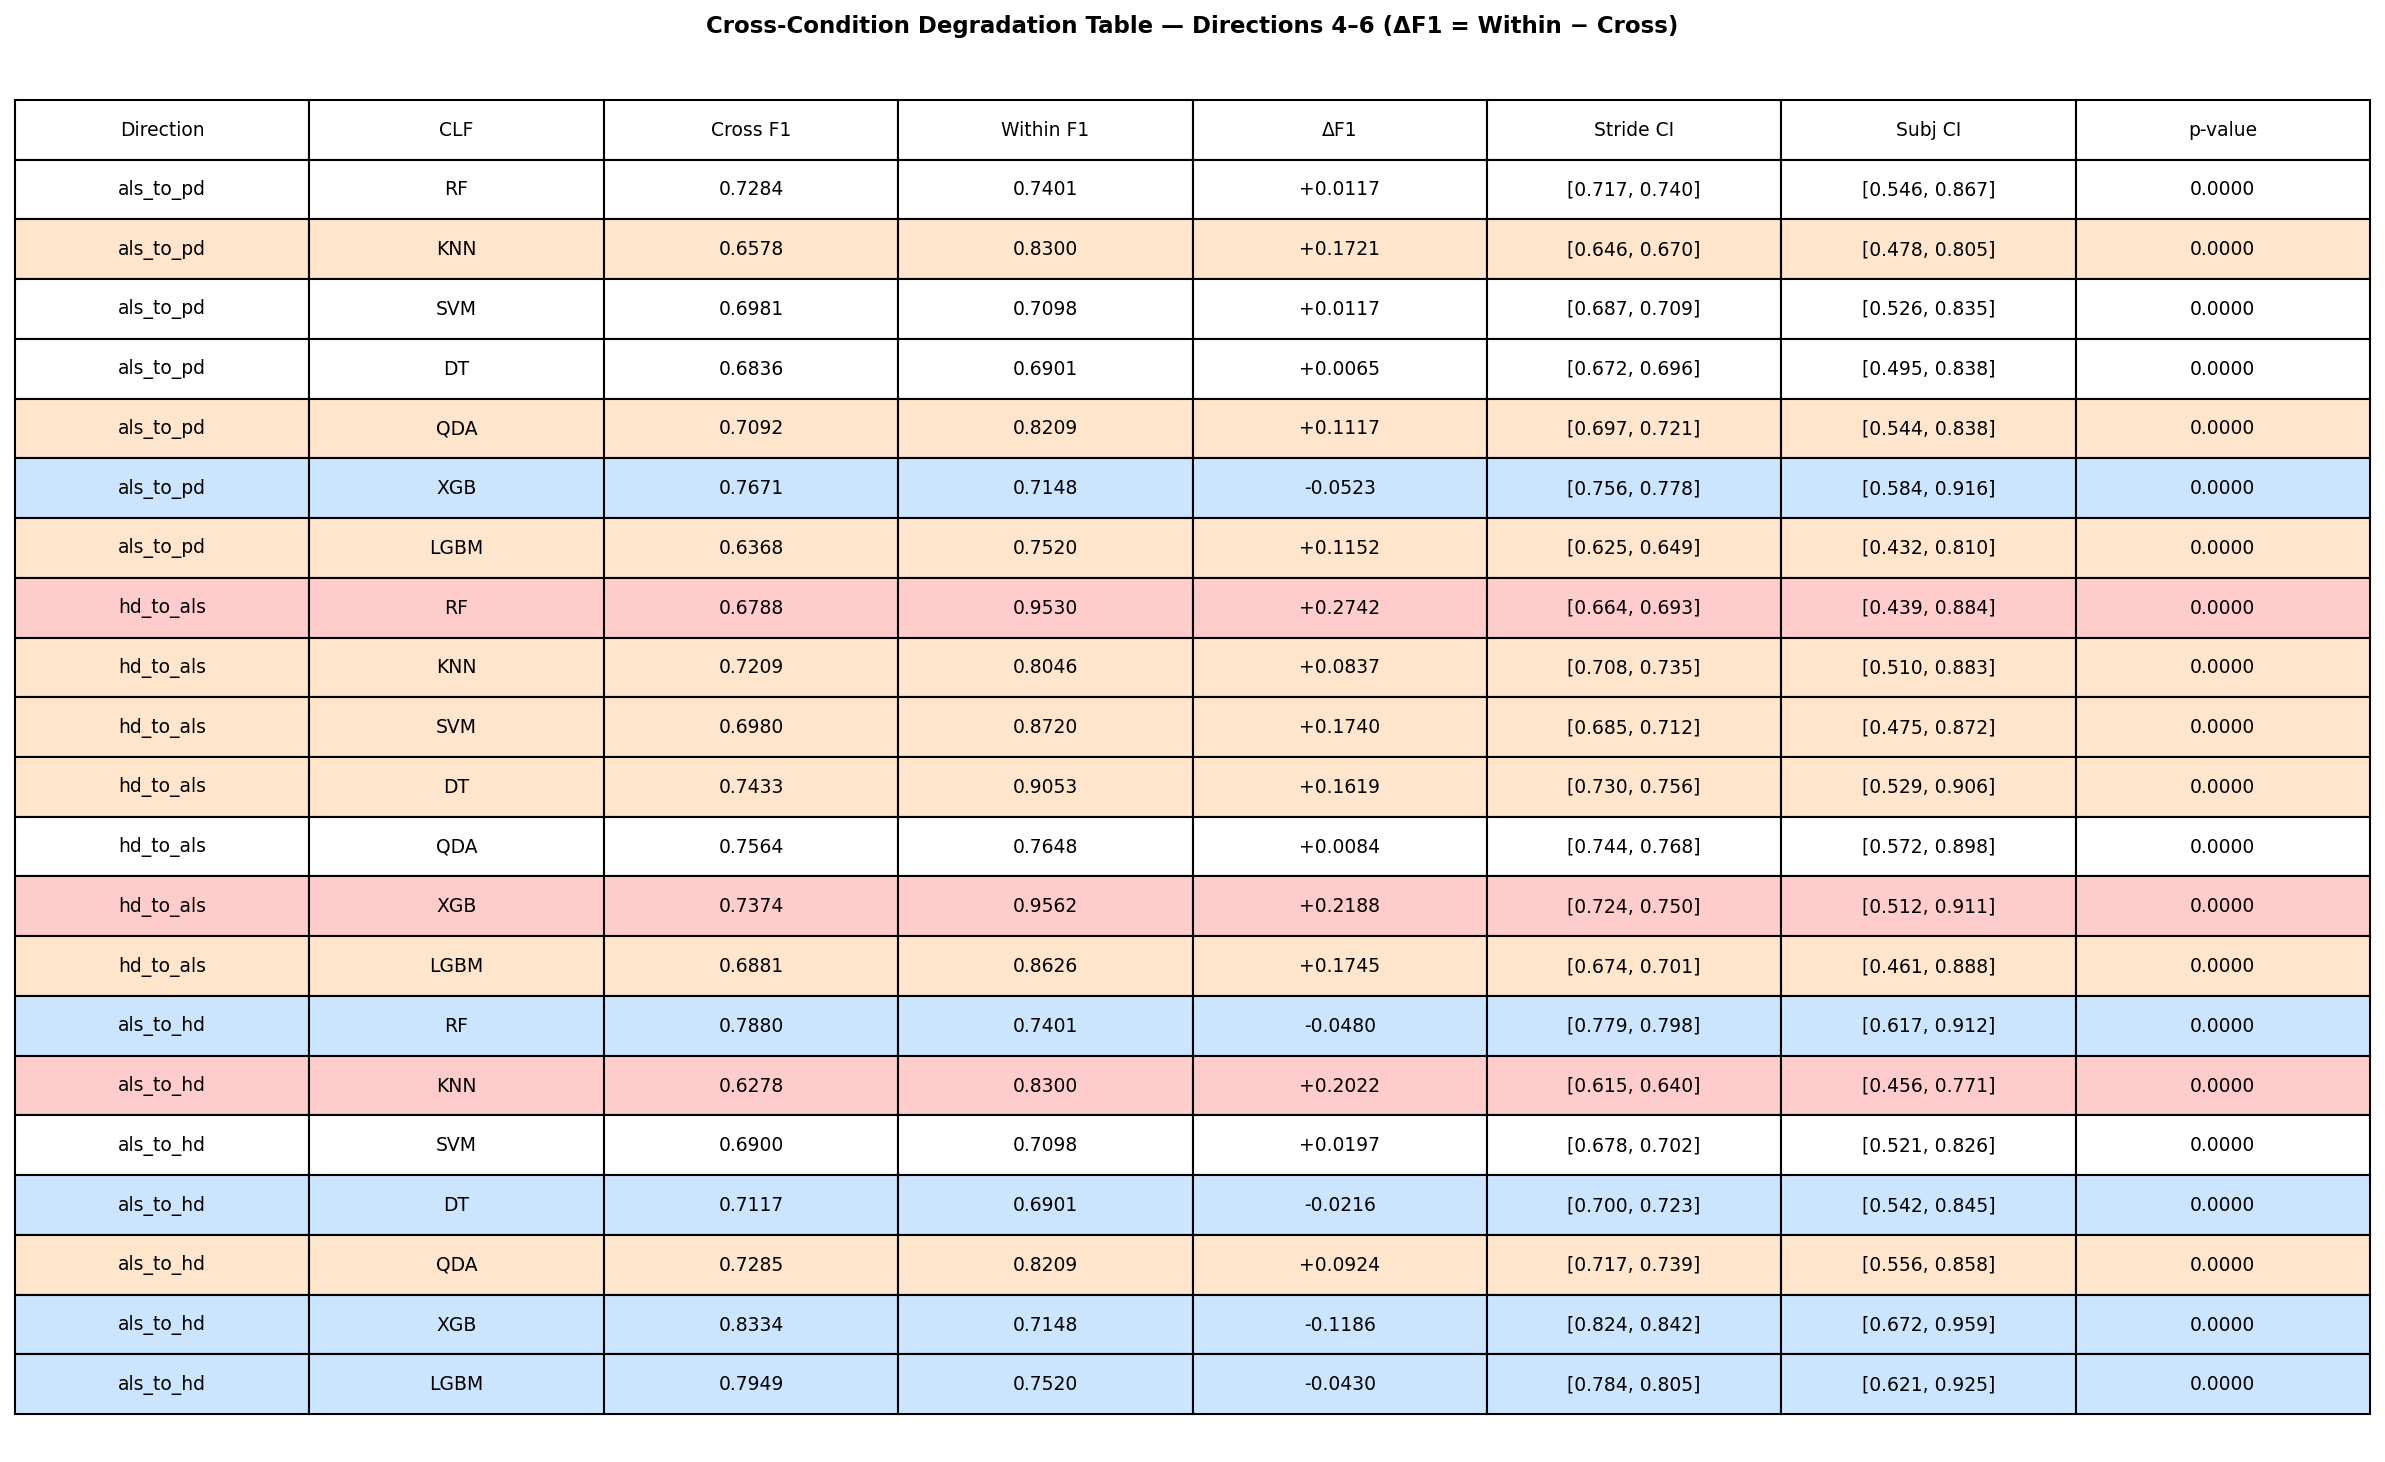

Saved: degradation_table_part2.pdf / .png


In [ ]:
rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    d = cc[direction]
    for clf in CLF_NAMES:
        v = d['classifiers'][clf]
        within_f1 = WITHIN_F1_PER_CLF[src][clf]
        rows.append({
            'direction':       direction,
            'clf':             clf,
            'cross_f1':        v['f1_macro'],
            'within_f1':       within_f1,
            'delta_f1':        round(within_f1 - v['f1_macro'], 6),
            'stride_ci_lower': v['f1_macro_ci_lower'],
            'stride_ci_upper': v['f1_macro_ci_upper'],
            'subj_ci_lower':   v['f1_macro_subj_ci_lower'],
            'subj_ci_upper':   v['f1_macro_subj_ci_upper'],
            'p_value':         v['permutation_p_value'],
        })

df_deg = pd.DataFrame(rows)

styled = (
    df_deg.style
    .background_gradient(subset=['delta_f1'], cmap='RdBu_r', vmin=-0.45, vmax=0.45)
    .format({
        'cross_f1':        '{:.4f}',
        'within_f1':       '{:.4f}',
        'delta_f1':        '{:+.4f}',
        'stride_ci_lower': '{:.4f}',
        'stride_ci_upper': '{:.4f}',
        'subj_ci_lower':   '{:.4f}',
        'subj_ci_upper':   '{:.4f}',
        'p_value':         '{:.4f}',
    })
    .set_caption('Cross-Condition Degradation Table (\u0394F1 = Within \u2212 Cross, per classifier)')
)
display(styled)

# Matplotlib table for PDF rendering \u2014 split into two halves for readability
for half_idx, (half_label, half_df) in enumerate(
    [('Directions 1\u20133', df_deg.iloc[:21]), ('Directions 4\u20136', df_deg.iloc[21:])],
    start=1
):
    fig_t, ax_t = plt.subplots(figsize=(16, 10))
    ax_t.axis('off')

    col_labels = ['Direction', 'CLF', 'Cross F1', 'Within F1', '\u0394F1',
                  'Stride CI', 'Subj CI', 'p-value']
    table_data = []
    row_colors = []
    for _, row in half_df.iterrows():
        table_data.append([
            row['direction'], row['clf'].upper(),
            f"{row['cross_f1']:.4f}",
            f"{row['within_f1']:.4f}",
            f"{row['delta_f1']:+.4f}",
            f"[{row['stride_ci_lower']:.3f}, {row['stride_ci_upper']:.3f}]",
            f"[{row['subj_ci_lower']:.3f}, {row['subj_ci_upper']:.3f}]",
            f"{row['p_value']:.4f}",
        ])
        delta = row['delta_f1']
        if delta > 0.20:
            row_colors.append(['#ffcccc'] * 8)
        elif delta > 0.05:
            row_colors.append(['#ffe5cc'] * 8)
        elif delta < -0.01:
            row_colors.append(['#cce5ff'] * 8)
        else:
            row_colors.append(['#ffffff'] * 8)

    tbl = ax_t.table(
        cellText=table_data,
        colLabels=col_labels,
        cellColours=row_colors,
        loc='center',
        cellLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 2.0)

    # Title placed well above the table using figure text, not ax title
    fig_t.text(0.5, 0.97,
               f'Cross-Condition Degradation Table \u2014 {half_label} (\u0394F1 = Within \u2212 Cross)',
               ha='center', va='top', fontsize=11, fontweight='bold')

    fig_t.tight_layout(rect=[0, 0, 1, 0.95])
    fig_t.savefig(FIGURES_PDF / f'degradation_table_part{half_idx}.pdf')
    fig_t.savefig(FIGURES_PNG / f'degradation_table_part{half_idx}.png')
    plt.show()
    plt.close(fig_t)
    print(f"Saved: degradation_table_part{half_idx}.pdf / .png")


### Cell 3 — Per-Subject Accuracy Analysis

Breaks down transfer performance at the individual patient level rather than the aggregate stride level. Each bar represents one subject's per-stride accuracy under the best source classifier (**DT** for PD source, **XGBoost** for HD source, **KNN** for ALS source). Disease subjects (red) are separated from Control B subjects (blue) by a vertical dotted line.

**What to look for:** Wide within-group variance is the normal finding. `ALS→PD` and `ALS→HD` still show several difficult disease subjects, but the stored output also shows complete failures in other directions, including individual HD subjects in `PD→HD` and individual PD/control subjects in `HD→PD`. This subject-level heterogeneity is why subject-level CIs are far wider than stride-level CIs: a single patient can be entirely misclassified without moving the aggregate F1 very much if other patients compensate.


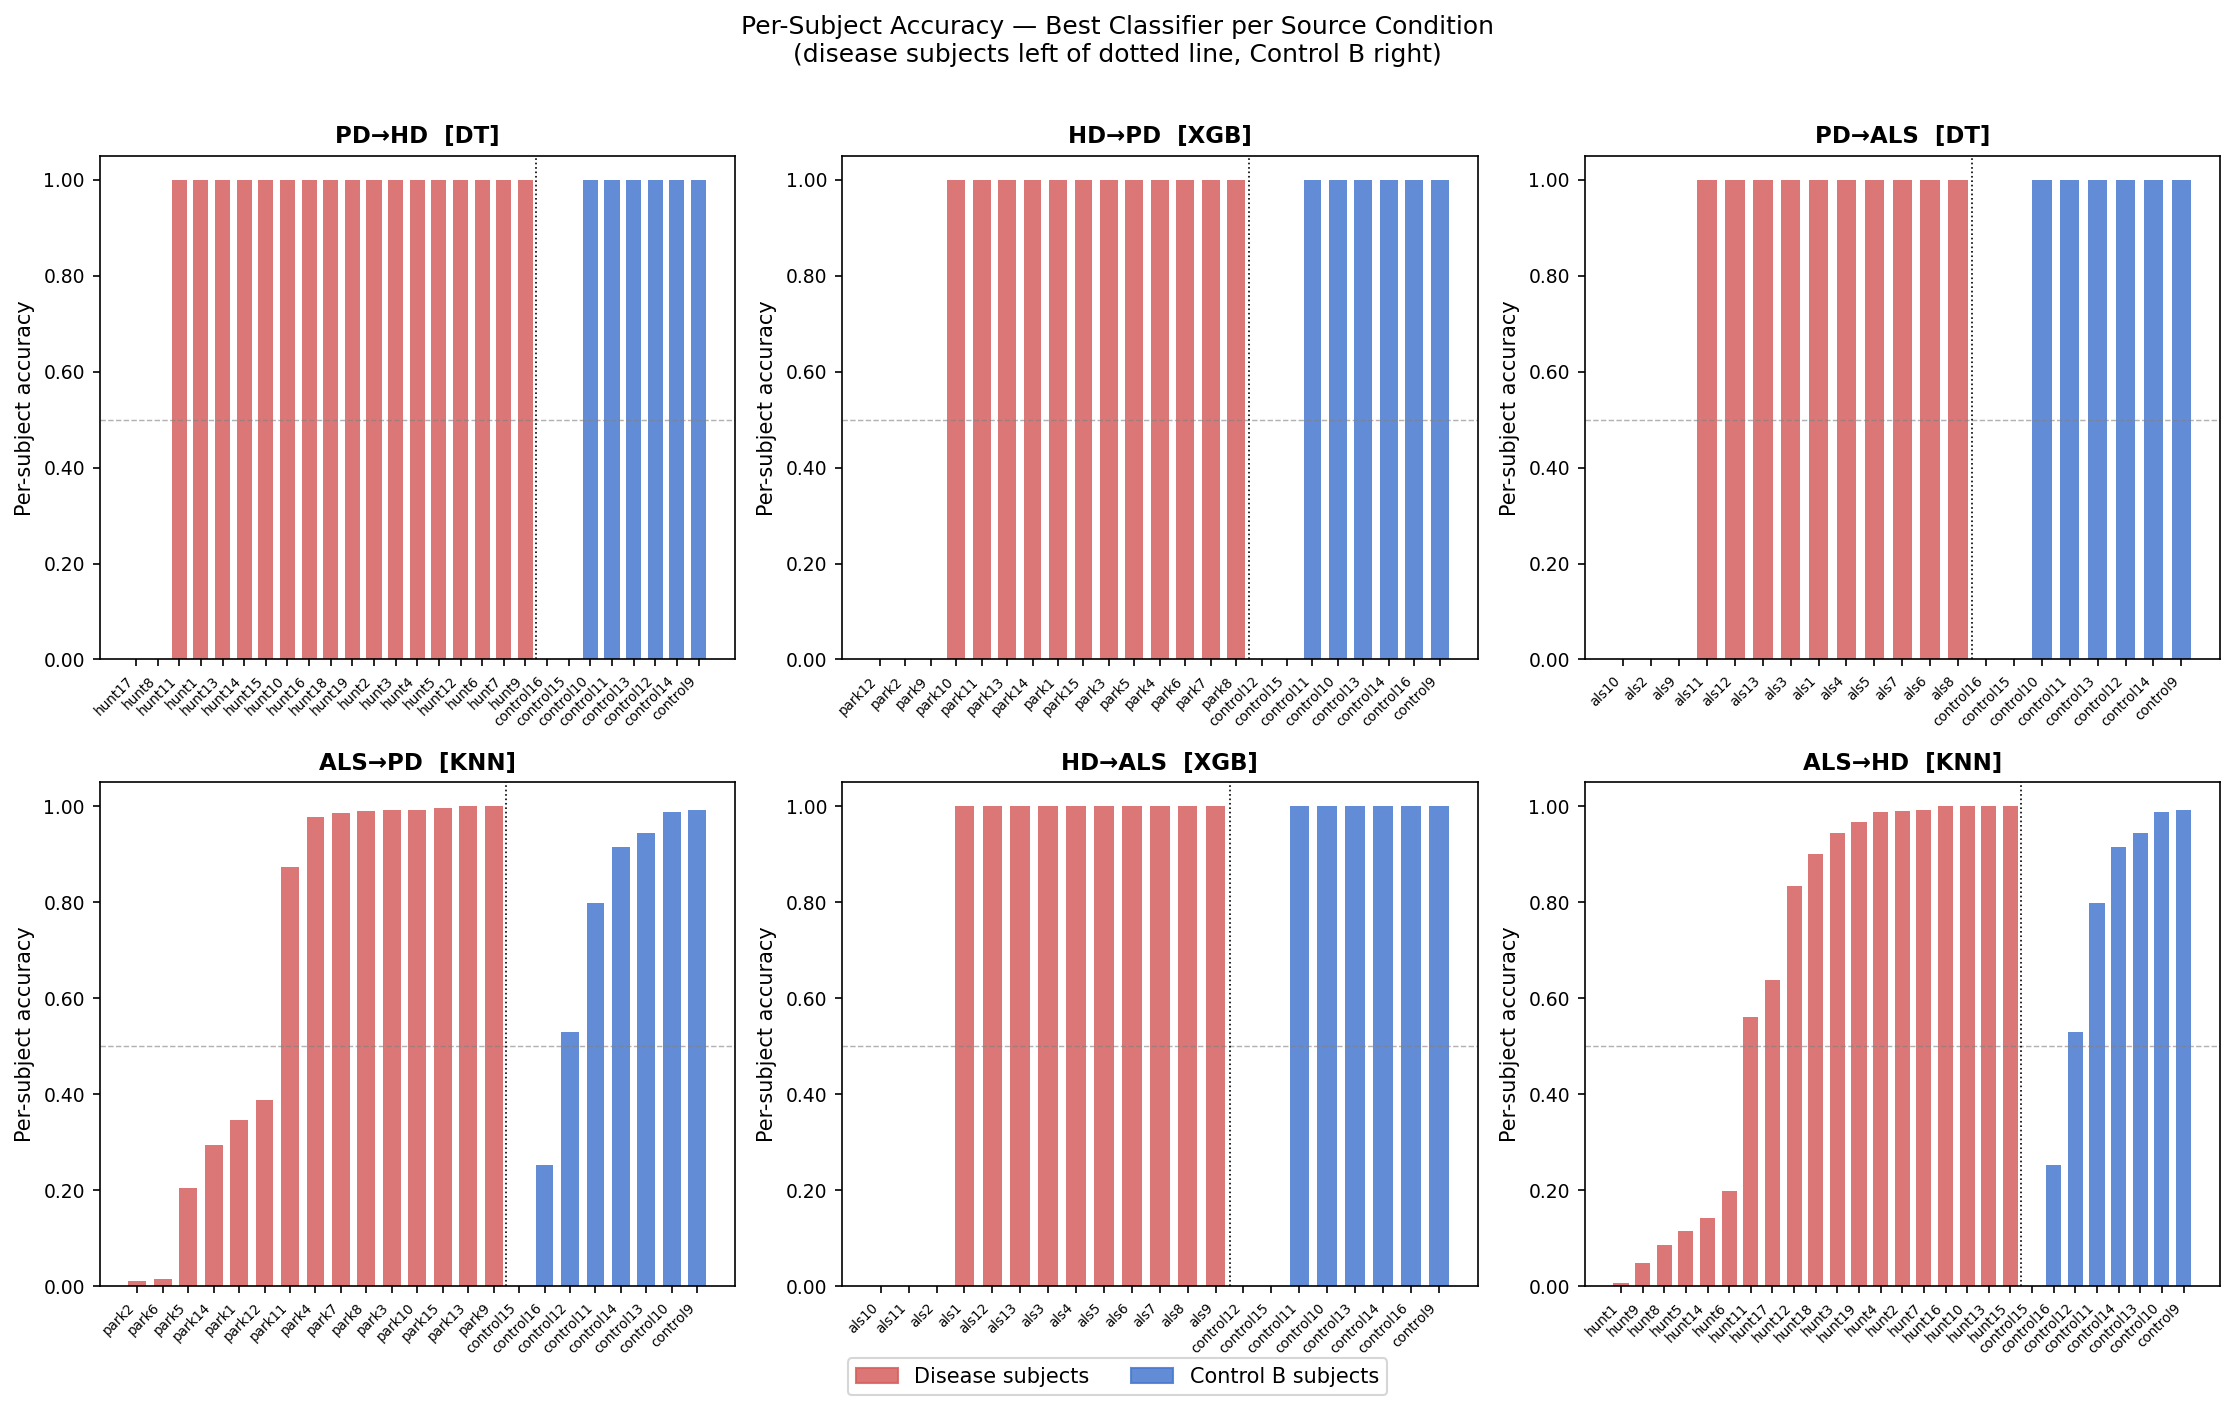

Saved: per_subject_accuracy.pdf / .png

Per-subject accuracy summary (all directions, best clf per source):
                     count   mean    min    max
dir_label condition                            
ALS→HD    control        8  0.678  0.000  0.993
          disease       19  0.653  0.006  1.000
ALS→PD    control        8  0.678  0.000  0.993
          disease       15  0.671  0.011  1.000
HD→ALS    control        8  0.750  0.000  1.000
          disease       13  0.769  0.000  1.000
HD→PD     control        8  0.750  0.000  1.000
          disease       15  0.800  0.000  1.000
PD→ALS    control        8  0.750  0.000  1.000
          disease       13  0.769  0.000  1.000
PD→HD     control        8  0.750  0.000  1.000
          disease       19  0.895  0.000  1.000

Subjects with accuracy < 0.5 (transfer failure):
dir_label subject_id condition  n_strides  accuracy
    PD→HD  control15   control        198  0.000000
    PD→HD  control16   control        250  0.000000
    PD→HD     

In [ ]:
# ── Per-subject accuracy analysis ────────────────────────────────────────────
# Uses the best classifier per source condition (RF for PD/HD-source, KNN for ALS-source).
# Accuracy is used instead of F1 because each subject belongs to a single class,
# making F1 macro undefined for single-class test sets.
# target_subject_ids is stored at direction level (parallel to y_true / y_pred).

subj_rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    tgt = direction.split('_to_')[1]
    clf_name = BEST_CLF[src]
    d = cc[direction]

    y_true = np.array(d['classifiers'][clf_name]['y_true'])
    y_pred = np.array(d['classifiers'][clf_name]['y_pred'])
    subj_ids = np.array(d['target_subject_ids'])

    for sid in np.unique(subj_ids):
        mask = subj_ids == sid
        yt = y_true[mask]
        yp = y_pred[mask]
        acc = np.mean(yt == yp)
        label = int(yt[0])   # all strides from same subject share the same label
        subj_rows.append({
            'direction':  direction,
            'dir_label':  f"{src.upper()}→{tgt.upper()}",
            'subject_id': sid,
            'condition':  'disease' if label == 1 else 'control',
            'label':      label,
            'n_strides':  int(mask.sum()),
            'accuracy':   acc,
            'clf':        clf_name,
        })

df_subj = pd.DataFrame(subj_rows)

# ── Plot: 2×3 grouped bar chart, one subplot per direction ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
axes_flat = axes.flatten()

color_disease = '#D65F5F'
color_control = '#4878CF'

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    sub = df_subj[df_subj['direction'] == direction].copy()

    # Disease subjects first, then controls; within each group sort by accuracy
    disease = sub[sub['label'] == 1].sort_values('accuracy')
    control = sub[sub['label'] == 0].sort_values('accuracy')
    ordered = pd.concat([disease, control], ignore_index=True)

    colors = [color_disease if r == 1 else color_control for r in ordered['label']]
    x = np.arange(len(ordered))

    bars = ax.bar(x, ordered['accuracy'], color=colors, alpha=0.85, width=0.7)
    ax.axhline(0.5, color='gray', linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_title(f"{dir_label}  [{BEST_CLF[src].upper()}]", fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered['subject_id'], rotation=45, ha='right', fontsize=6.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Per-subject accuracy')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Vertical separator between disease and control groups
    n_disease = (ordered['label'] == 1).sum()
    if 0 < n_disease < len(ordered):
        ax.axvline(n_disease - 0.5, color='black', linewidth=0.8, linestyle=':')

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_disease, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_control, alpha=0.85),
]
fig.legend(handles, ['Disease subjects', 'Control B subjects'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Per-Subject Accuracy — Best Classifier per Source Condition\n'
             '(disease subjects left of dotted line, Control B right)',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PDF / f'per_subject_accuracy.pdf')
fig.savefig(FIGURES_PNG / f'per_subject_accuracy.png')
plt.show()
plt.close(fig)
print("Saved: per_subject_accuracy.pdf / .png")

print("\nPer-subject accuracy summary (all directions, best clf per source):")
summary = (df_subj.groupby(['dir_label', 'condition'])['accuracy']
           .agg(['count', 'mean', 'min', 'max'])
           .round(3))
print(summary.to_string())
print(f"\nSubjects with accuracy < 0.5 (transfer failure):")
failures = df_subj[df_subj['accuracy'] < 0.5][['dir_label', 'subject_id', 'condition', 'n_strides', 'accuracy']]
print(failures.to_string(index=False) if len(failures) > 0 else "  None")


### Cell 4 — ΔF1 Degradation Heatmap (Primary Publication Figure)

A 7-classifier × 6-direction heatmap with diverging RdBu_r colormap centred at zero. Blue = improvement (negative ΔF1), red = degradation (positive ΔF1). Each cell shows ΔF1 = within F1 − cross F1 for that (classifier, direction) pair.

**What to look for:** `PD→HD` is **mostly blue rather than uniformly blue**: 5 of 7 classifiers improve, but KNN (`+0.0565`) and DT (`+0.0355`) still degrade slightly. `HD→ALS` is the most consistently severe degradation column: all 7 classifiers are positive, led by RF (`+0.2742`), XGBoost (`+0.2188`), and SVM (`+0.1740`). `ALS→HD` is mixed rather than uniformly red: RF, DT, XGBoost, and LightGBM improve, while KNN (`+0.2022`), SVM (`+0.0197`), and QDA (`+0.0924`) degrade.


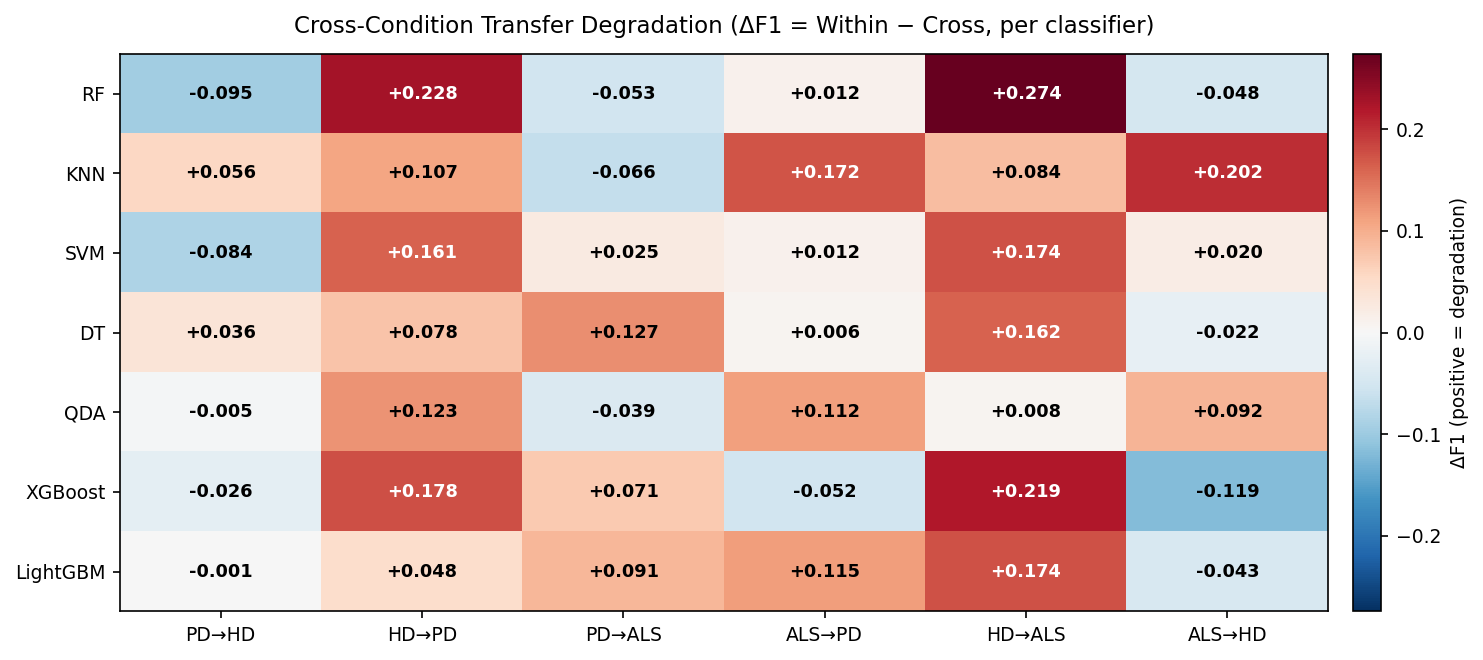

Saved: degradation_heatmap.pdf / .png


In [ ]:
# Build matrix: rows = classifiers, cols = directions, using per-classifier within-F1
delta_matrix = np.zeros((len(CLF_NAMES), len(DIRECTIONS)))
for j, direction in enumerate(DIRECTIONS):
    src = direction.split('_to_')[0]
    for i, clf in enumerate(CLF_NAMES):
        delta_matrix[i, j] = WITHIN_F1_PER_CLF[src][clf] - cc[direction]['classifiers'][clf]['f1_macro']

abs_max = np.abs(delta_matrix).max()
vmax = max(abs_max, 0.01)   # guard against degenerate coloring

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(delta_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(DIRECTIONS)))
ax.set_xticklabels(DIR_LABELS, rotation=0)
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_title('Cross-Condition Transfer Degradation (ΔF1 = Within − Cross, per classifier)', pad=10)

# Annotate each cell
for i in range(len(CLF_NAMES)):
    for j in range(len(DIRECTIONS)):
        val = delta_matrix[i, j]
        brightness = abs(val) / vmax
        color = 'white' if brightness > 0.55 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('ΔF1 (positive = degradation)', fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_PDF / f'degradation_heatmap.pdf')
fig.savefig(FIGURES_PNG / f'degradation_heatmap.png')
plt.show()
plt.close(fig)
print("Saved: degradation_heatmap.pdf / .png")


### Cell 4b — Cross-Condition F1 Heatmap

This heatmap shows the raw cross-condition F1 surface directly, without subtracting the within-condition baseline. It complements the degradation heatmap by showing where transfer is actually strongest or weakest in absolute terms.


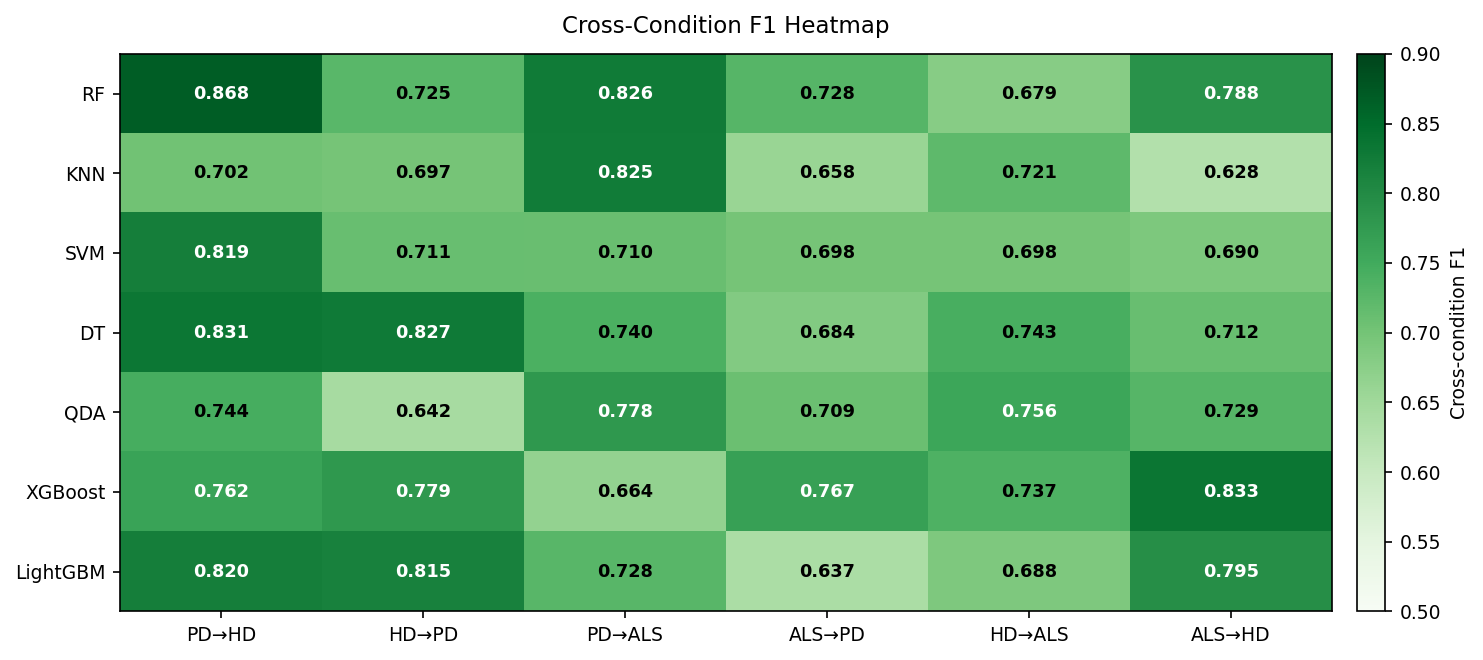

Saved: cross_condition_f1_heatmap.pdf / .png


In [ ]:
cross_matrix = np.zeros((len(CLF_NAMES), len(DIRECTIONS)))
for j, direction in enumerate(DIRECTIONS):
    for i, clf in enumerate(CLF_NAMES):
        cross_matrix[i, j] = cc[direction]['classifiers'][clf]['f1_macro']

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(cross_matrix, cmap='Greens', aspect='auto', vmin=0.5, vmax=0.9)
ax.set_xticks(range(len(DIRECTIONS)))
ax.set_xticklabels(DIR_LABELS)
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_title('Cross-Condition F1 Heatmap', pad=10)

for i in range(len(CLF_NAMES)):
    for j in range(len(DIRECTIONS)):
        val = cross_matrix[i, j]
        color = 'white' if val > 0.75 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8.5, color=color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Cross-condition F1', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'cross_condition_f1_heatmap.pdf')
fig.savefig(FIGURES_PNG / 'cross_condition_f1_heatmap.png')
plt.show()
print('Saved: cross_condition_f1_heatmap.pdf / .png')


### Cell 4c — Bidirectional ΔF1 Asymmetry

This figure pairs each bidirectional condition pair and shows how much the degradation changes when source and target are swapped. Each dumbbell corresponds to one classifier.


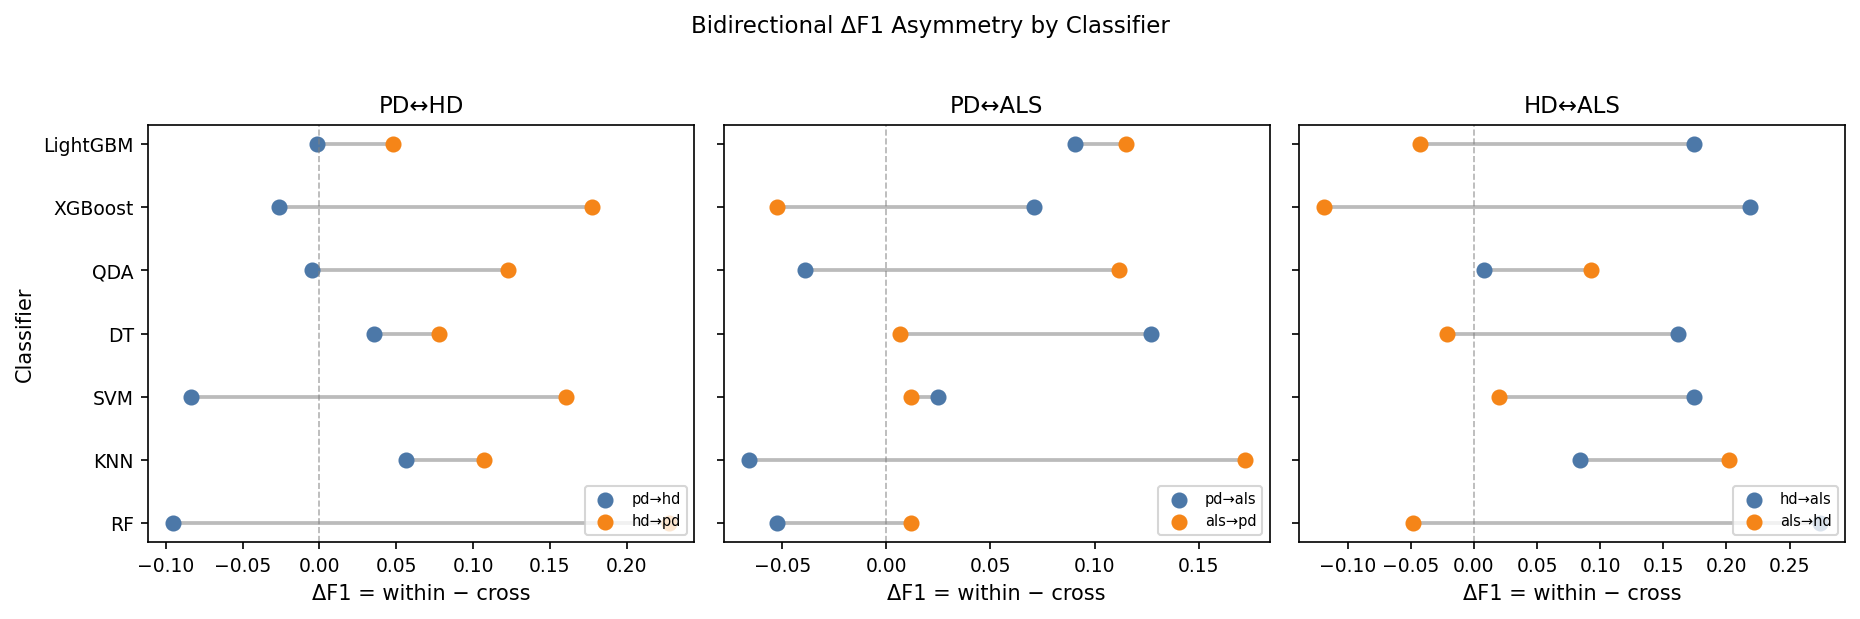

Saved: delta_f1_asymmetry_pairs.pdf / .png


In [ ]:
pair_specs = [
    ('pd_to_hd', 'hd_to_pd', 'PD↔HD'),
    ('pd_to_als', 'als_to_pd', 'PD↔ALS'),
    ('hd_to_als', 'als_to_hd', 'HD↔ALS'),
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), sharey=True)
for ax, (d1, d2, title) in zip(axes, pair_specs):
    src1 = d1.split('_to_')[0]
    src2 = d2.split('_to_')[0]
    vals1 = np.array([WITHIN_F1_PER_CLF[src1][clf] - cc[d1]['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES])
    vals2 = np.array([WITHIN_F1_PER_CLF[src2][clf] - cc[d2]['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES])
    y = np.arange(len(CLF_NAMES))
    for i in range(len(CLF_NAMES)):
        ax.plot([vals1[i], vals2[i]], [y[i], y[i]], color='#BBBBBB', linewidth=1.8, zorder=1)
    ax.scatter(vals1, y, color='#4C78A8', s=45, label=d1.replace('_to_', '→'), zorder=2)
    ax.scatter(vals2, y, color='#F58518', s=45, label=d2.replace('_to_', '→'), zorder=2)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(CLF_LABELS)
    ax.set_title(title)
    ax.set_xlabel('ΔF1 = within − cross')
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_ylabel('Classifier')
fig.suptitle('Bidirectional ΔF1 Asymmetry by Classifier', fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'delta_f1_asymmetry_pairs.pdf')
fig.savefig(FIGURES_PNG / 'delta_f1_asymmetry_pairs.png')
plt.show()
print('Saved: delta_f1_asymmetry_pairs.pdf / .png')


### Cell 5 — Within-Condition vs Cross-Condition F1 by Direction (with Stride CIs)

Six paired bar charts — one per direction — comparing each classifier's within-condition F1 (blue) to its cross-condition F1 (red) with ±stride-level 95% bootstrap CI error bars.

**What to look for:** `PD→HD` is the clearest near-parity case overall, but not every classifier improves: RF, SVM, QDA, XGBoost, and LightGBM transfer above their PD within baselines, while KNN and DT sit slightly below. For HD-source transfer, the largest blue-versus-red gaps occur in `HD→ALS`, especially for RF (`0.9530` within vs `0.6788` cross, gap `+0.2742`), XGBoost (`0.9562` vs `0.7374`, gap `+0.2188`), and SVM (`0.8720` vs `0.6980`, gap `+0.1740`). QDA no longer inverts the HD-source gap in the authoritative v2 run; it stays slightly positive in both `HD→PD` (`+0.1229`) and `HD→ALS` (`+0.0084`). Stride-level CIs are narrow relative to subject-level CIs, so the next cell is needed for a patient-level uncertainty view.


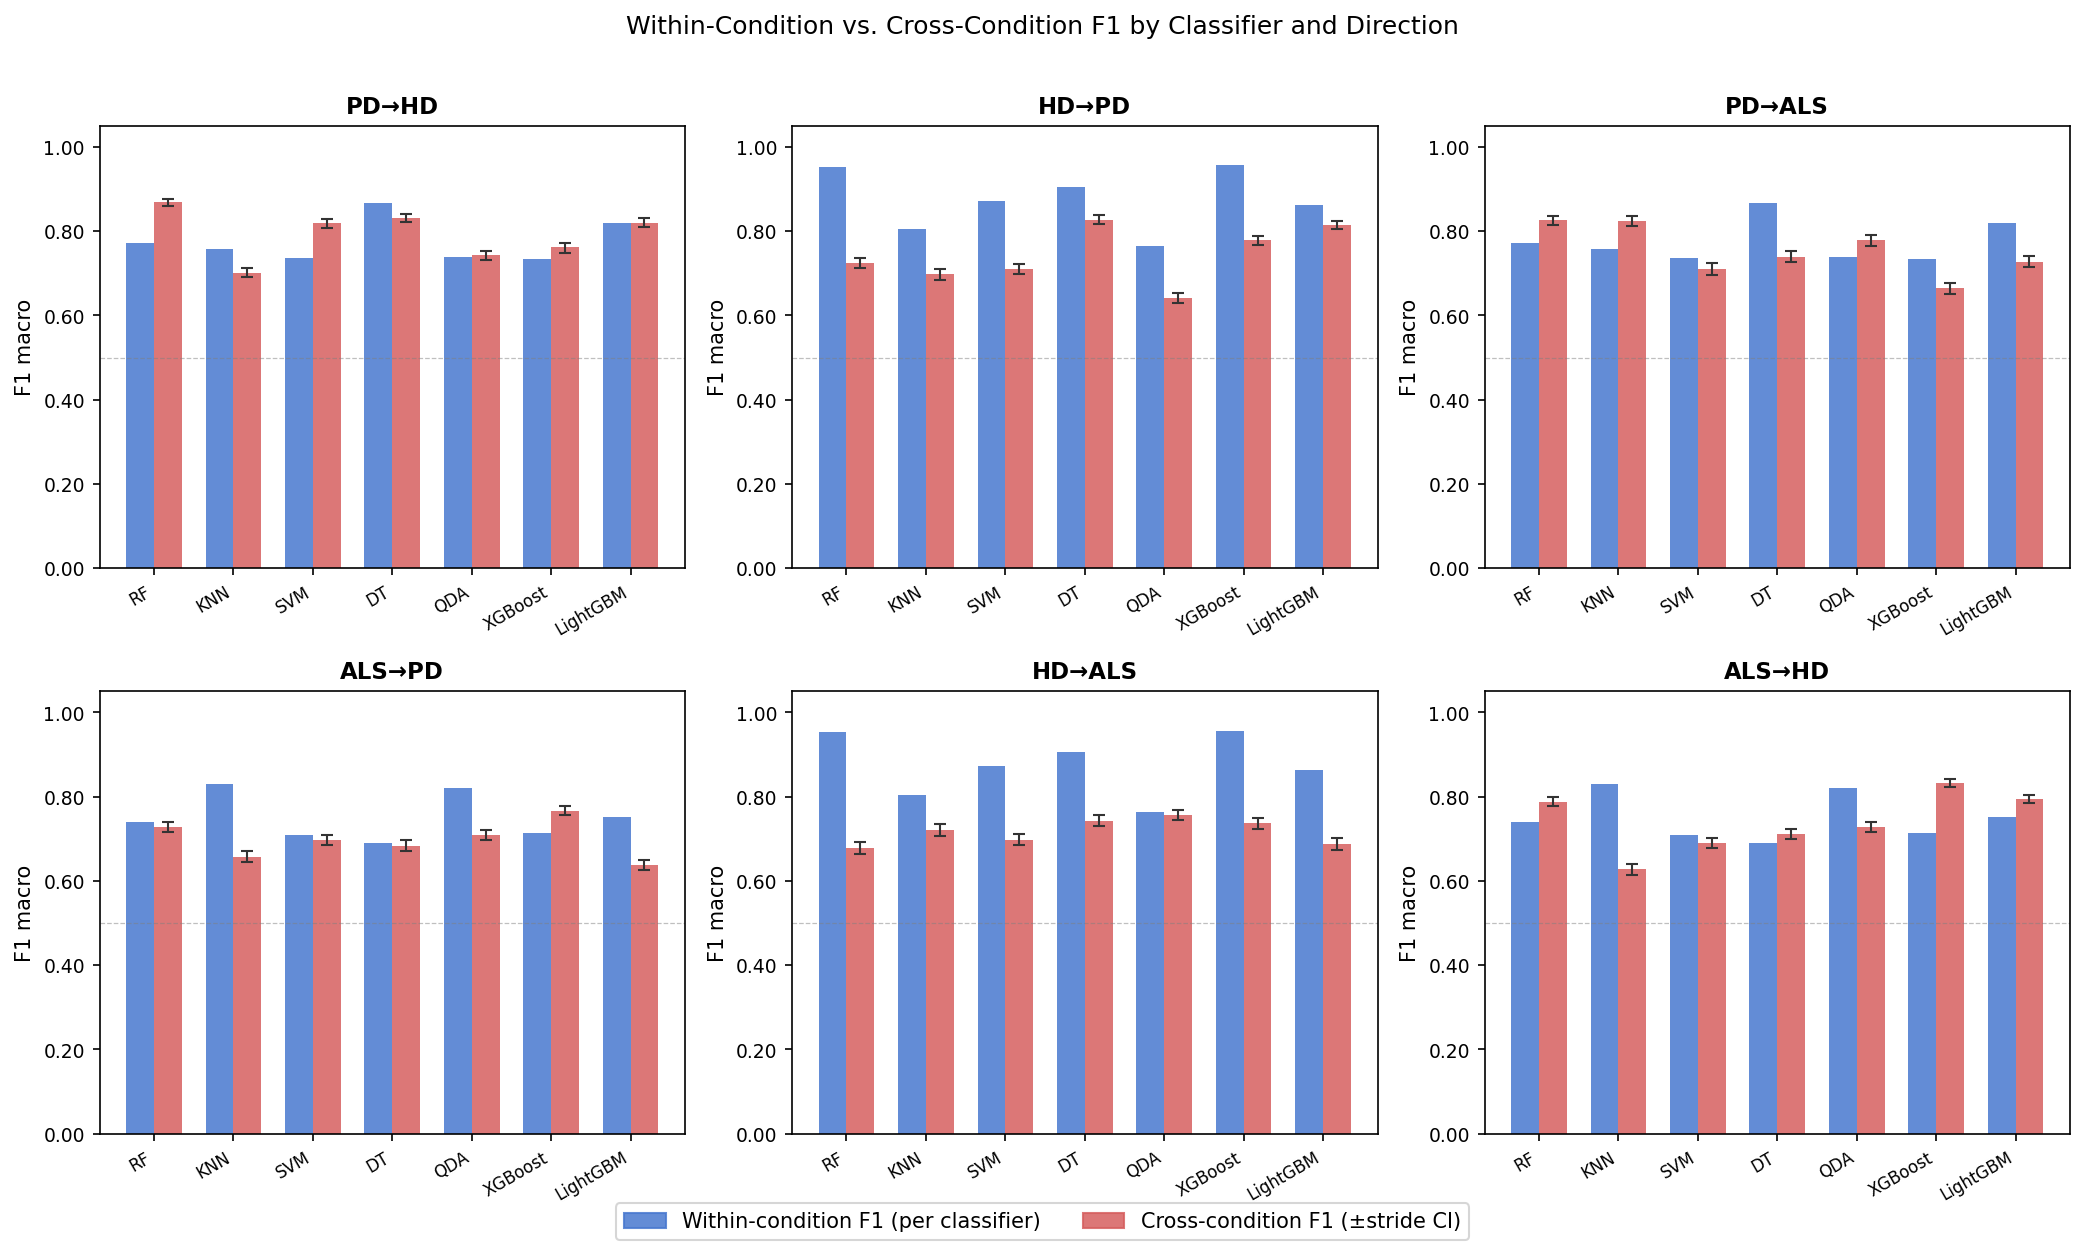

Saved: within_vs_cross_f1.pdf / .png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

color_within = '#4878CF'
color_cross  = '#D65F5F'

x = np.arange(len(CLF_NAMES))
width = 0.35

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    d = cc[direction]

    cross_f1s   = [d['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES]
    ci_lowers   = [d['classifiers'][clf]['f1_macro_ci_lower'] for clf in CLF_NAMES]
    ci_uppers   = [d['classifiers'][clf]['f1_macro_ci_upper'] for clf in CLF_NAMES]
    ci_errs     = np.array([
        [c - lo for c, lo in zip(cross_f1s, ci_lowers)],
        [hi - c for c, hi in zip(cross_f1s, ci_uppers)],
    ])

    # Each classifier's own within-condition baseline (not a single shared value)
    within_bars = [WITHIN_F1_PER_CLF[src][clf] for clf in CLF_NAMES]

    b1 = ax.bar(x - width/2, within_bars, width, label='Within-condition',
                color=color_within, alpha=0.85)
    b2 = ax.bar(x + width/2, cross_f1s, width, label='Cross-condition',
                color=color_cross, alpha=0.85,
                yerr=ci_errs, capsize=3, ecolor='#333333', error_kw={'linewidth': 1})

    ax.set_title(dir_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 macro')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.axhline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

# Single legend outside the subplots
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_within, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_cross, alpha=0.85),
]
fig.legend(handles, ['Within-condition F1 (per classifier)', 'Cross-condition F1 (±stride CI)'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Within-Condition vs. Cross-Condition F1 by Classifier and Direction',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PDF / f'within_vs_cross_f1.pdf')
fig.savefig(FIGURES_PNG / f'within_vs_cross_f1.png')
plt.show()
plt.close(fig)
print("Saved: within_vs_cross_f1.pdf / .png")


### Cell 6 — Normalised Confusion Matrices (Best Classifier per Source)

Six row-normalised confusion matrices showing the clinical failure mode for each direction. Best classifier per source: **DT** for PD source, **XGBoost** for HD source, **KNN** for ALS source.

**What to look for:** `PD→HD` (DT) has high disease recall (`0.890`) with moderate control recall (`0.777`), so the transferred PD model still flags most HD patients correctly. `HD→PD` (XGBoost) shows comparatively balanced errors (`control recall = 0.780`, `disease recall = 0.797`). `ALS→PD` (KNN) and `ALS→HD` (KNN) have the weakest disease recall among the best-source panels (`0.647` and `0.619`), but the failure mode is a broad softening of both recalls rather than a complete collapse of disease detection.


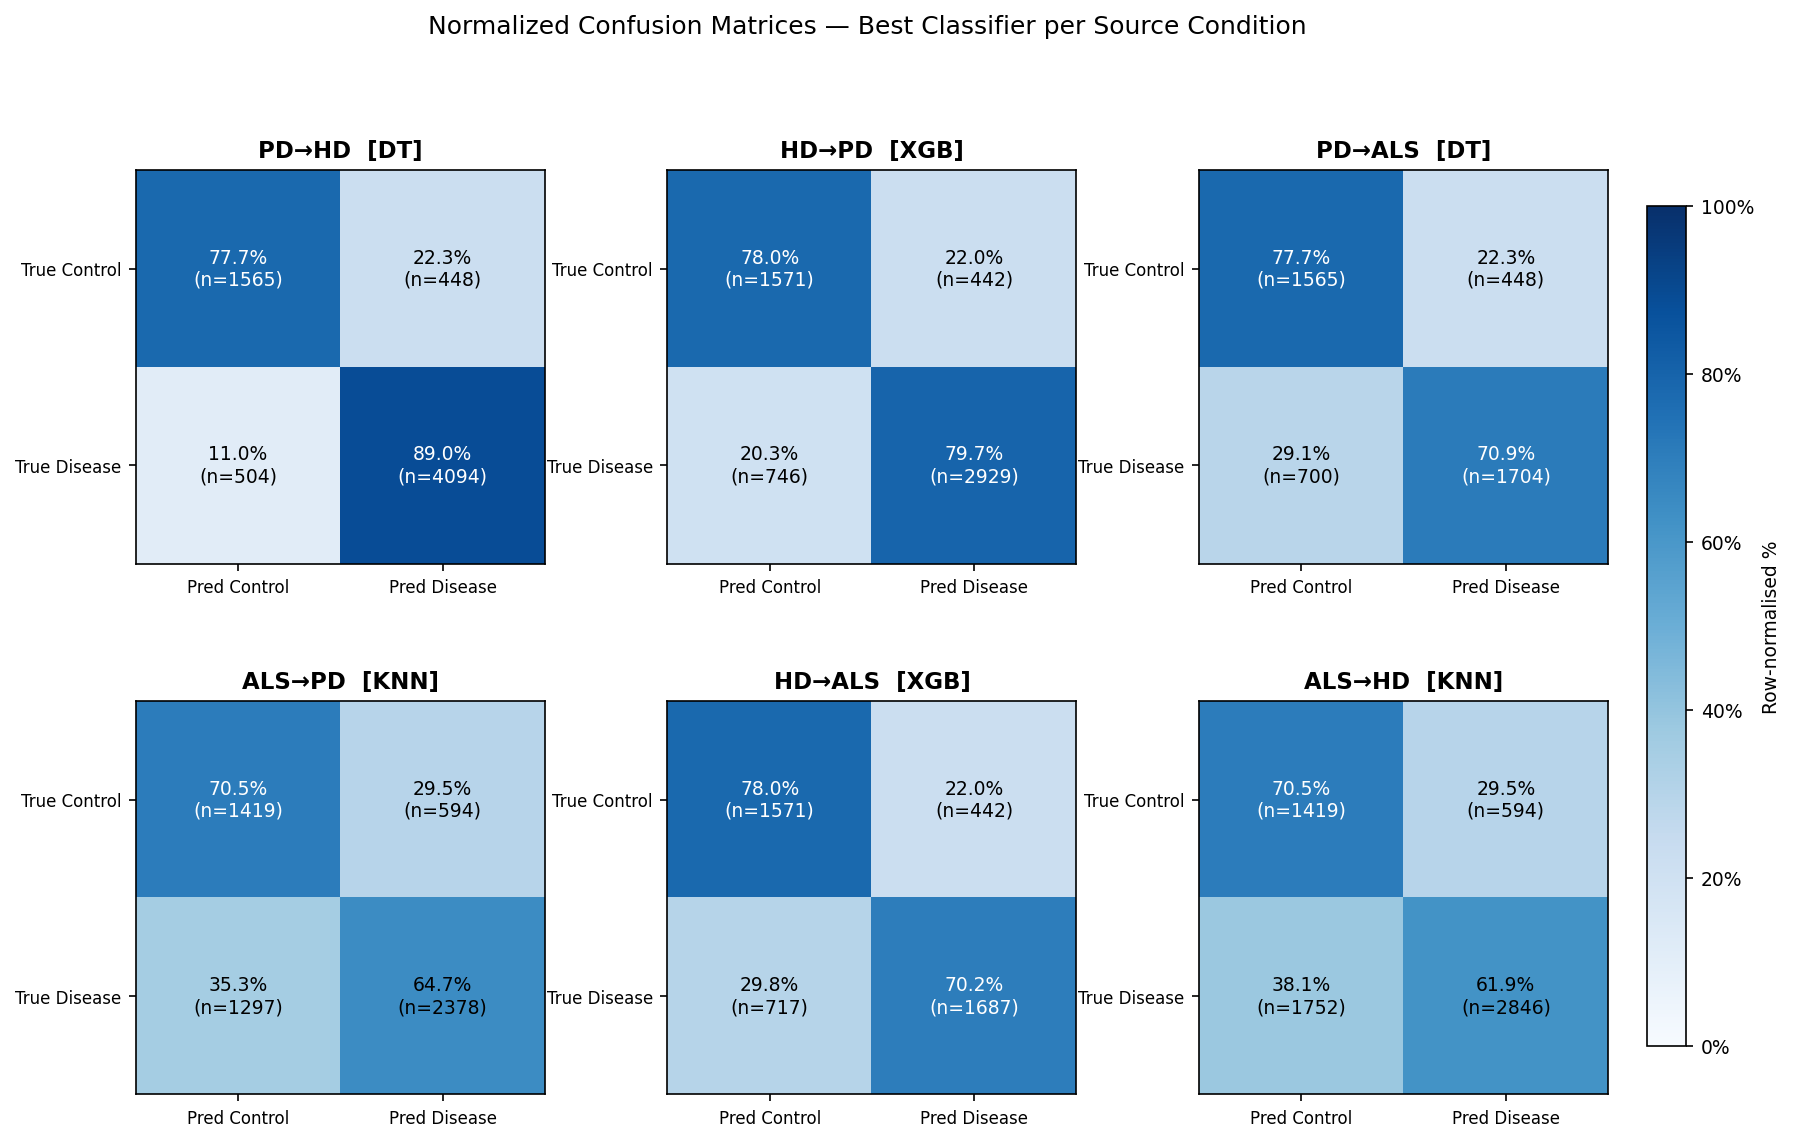

Saved: cross_condition_cms.pdf / .png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

last_im = None   # track final imshow handle for the shared colorbar

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    clf_name = BEST_CLF[src]
    v = cc[direction]['classifiers'][clf_name]

    y_true = np.array(v['y_true'])
    y_pred = np.array(v['y_pred'])

    cm = confusion_matrix(y_true, y_pred)
    # Row-normalize to percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    last_im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100, aspect='auto')

    for r in range(2):
        for c in range(2):
            color = 'white' if cm_norm[r, c] > 65 else 'black'
            ax.text(c, r, f'{cm_norm[r, c]:.1f}%\n(n={cm[r, c]})',
                    ha='center', va='center', fontsize=9, color=color)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Control', 'Pred Disease'], fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Control', 'True Disease'], fontsize=8)
    ax.set_title(f'{dir_label}  [{clf_name.upper()}]', fontweight='bold')

# Manual colorbar placement to avoid overlapping subplots
fig.suptitle('Normalized Confusion Matrices — Best Classifier per Source Condition',
             fontsize=12, y=1.01)
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(last_im, cax=cbar_ax, format='%.0f%%')
cbar.set_label('Row-normalised %', fontsize=9)

fig.savefig(FIGURES_PDF / f'cross_condition_cms.pdf')
fig.savefig(FIGURES_PNG / f'cross_condition_cms.png')
plt.show()
plt.close(fig)
print("Saved: cross_condition_cms.pdf / .png")


### Cell 7 — Bootstrap CI Width: Stride-Level vs. Subject-Level

Side-by-side bar charts comparing stride-level and subject-level 95% bootstrap CI widths for all 7 classifiers across the 6 directions. Subject-level CIs are computed by resampling subjects with replacement (preserving all strides per resampled subject); stride-level CIs resample individual strides.

**What to look for:** Subject-level CIs are consistently much wider than stride-level CIs. Among the best-source panels, the widest subject-level interval is `HD→ALS` with XGBoost (`[0.512, 0.911]`, width `0.399`), while `ALS→PD` KNN (`[0.478, 0.805]`, width `0.327`) and `ALS→HD` KNN (`[0.456, 0.771]`, width `0.314`) are also broad. By comparison, the corresponding stride-level widths sit near `0.019–0.026`, so the subject-level intervals are wider by roughly `0.289–0.372` F1 units. This is why the paper should report subject-level uncertainty, not just stride-level uncertainty.


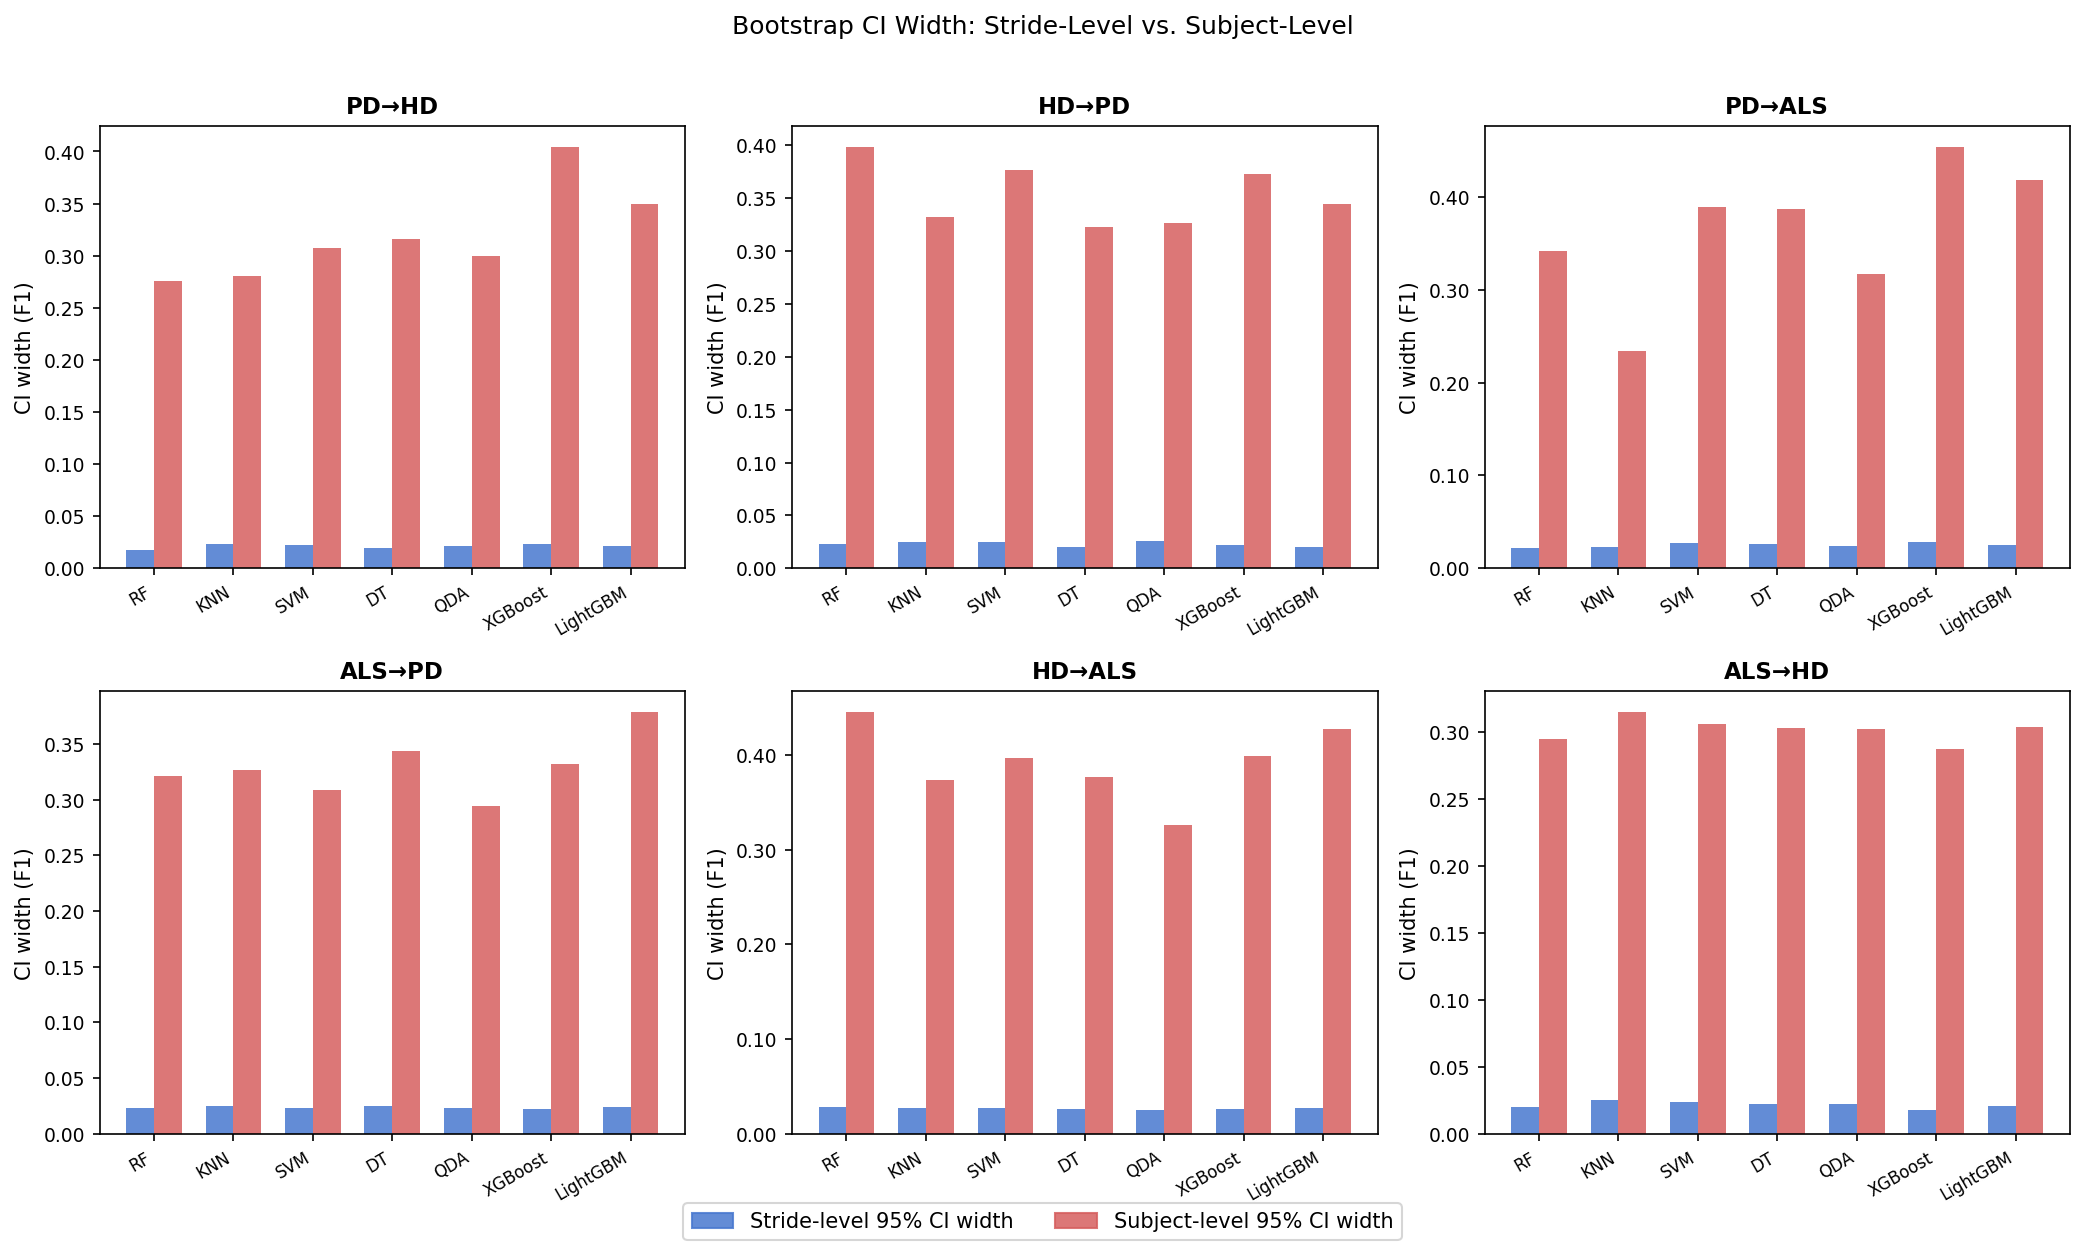

Saved: ci_width_comparison.pdf / .png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

color_stride = '#4878CF'
color_subj   = '#D65F5F'

x = np.arange(len(CLF_NAMES))
width = 0.35

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    d = cc[direction]

    stride_widths = [
        d['classifiers'][clf]['f1_macro_ci_upper'] -
        d['classifiers'][clf]['f1_macro_ci_lower']
        for clf in CLF_NAMES
    ]
    subj_widths = [
        d['classifiers'][clf]['f1_macro_subj_ci_upper'] -
        d['classifiers'][clf]['f1_macro_subj_ci_lower']
        for clf in CLF_NAMES
    ]

    ax.bar(x - width/2, stride_widths, width, label='Stride-level CI',
           color=color_stride, alpha=0.85)
    ax.bar(x + width/2, subj_widths, width, label='Subject-level CI',
           color=color_subj, alpha=0.85)

    ax.set_title(dir_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('CI width (F1)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_stride, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_subj,   alpha=0.85),
]
fig.legend(handles, ['Stride-level 95% CI width', 'Subject-level 95% CI width'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Bootstrap CI Width: Stride-Level vs. Subject-Level',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PDF / f'ci_width_comparison.pdf')
fig.savefig(FIGURES_PNG / f'ci_width_comparison.png')
plt.show()
plt.close(fig)
print("Saved: ci_width_comparison.pdf / .png")


### Cell 8 — Per-Class Recall Table (Best Classifier per Source)

Decomposes aggregate F1 into control recall and disease recall separately, revealing whether transfer failure manifests as missing disease cases (low disease recall) or generating false alarms (low control recall).

**What to look for:** `ALS→PD` (KNN) and `ALS→HD` (KNN) show the weakest disease recall in the best-source panels (`0.647` and `0.619`), while control recall is `0.705` in both directions. `PD→HD` (DT) has high disease recall (`0.890`) and moderate control recall (`0.777`). `HD→PD` (XGBoost) remains comparatively balanced (`control = 0.780`, `disease = 0.797`), consistent with broad confusion rather than a strongly one-sided failure mode.


,direction,clf,control_recall,disease_recall,f1_macro
0,PD→HD,DT,0.777,0.890,0.8313
1,HD→PD,XGB,0.780,0.797,0.7785
2,PD→ALS,DT,0.777,0.709,0.7398
3,ALS→PD,KNN,0.705,0.647,0.6578
4,HD→ALS,XGB,0.780,0.702,0.7374
5,ALS→HD,KNN,0.705,0.619,0.6278


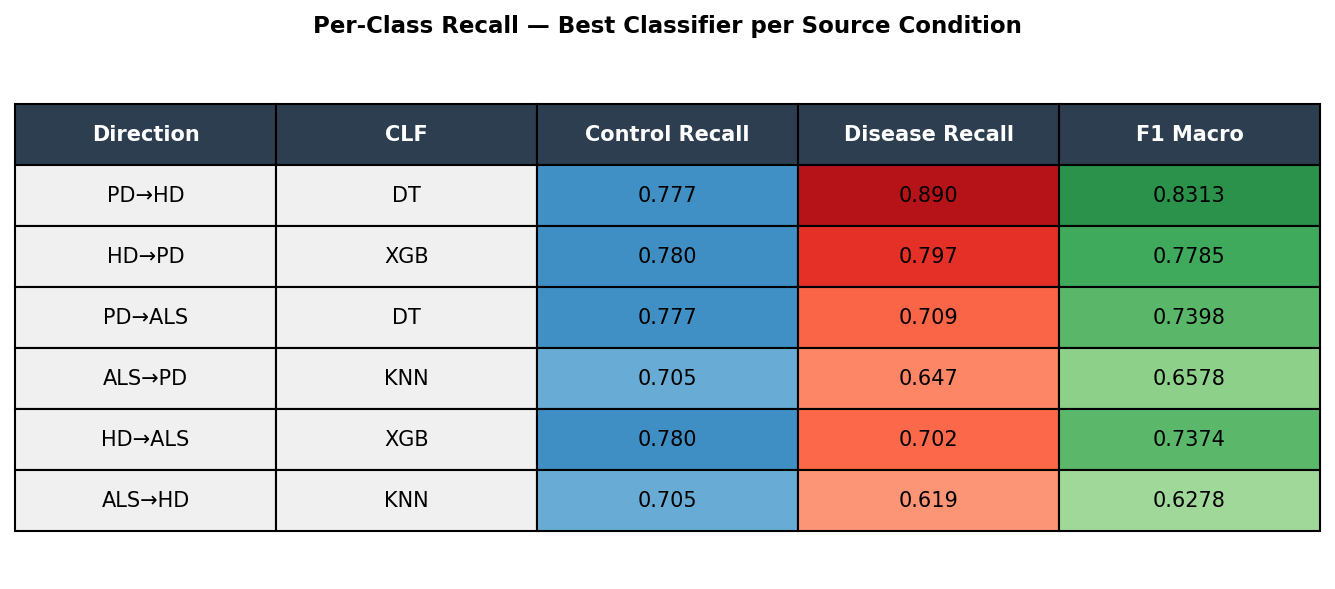

Saved: recall_table.pdf / .png


In [ ]:
# \u2500\u2500 Per-class recall breakdown \u2014 best classifier per source condition \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Control recall = fraction of control strides correctly classified as control.
# Disease recall = fraction of disease strides correctly classified as disease.
# These two numbers reveal the clinical failure mode: missed disease vs. false alarms.

recall_rows = []
for direction, dir_label in zip(DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    clf_name = BEST_CLF[src]
    v = cc[direction]['classifiers'][clf_name]

    y_true = np.array(v['y_true'])
    y_pred = np.array(v['y_pred'])
    cm = confusion_matrix(y_true, y_pred)

    # cm[0,0] = true negatives (control correct), cm[0,1] = false positives
    # cm[1,0] = false negatives (disease missed), cm[1,1] = true positives
    control_recall = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else float('nan')
    disease_recall = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else float('nan')

    recall_rows.append({
        'direction':      dir_label,
        'clf':            clf_name.upper(),
        'control_recall': control_recall,
        'disease_recall': disease_recall,
        'f1_macro':       v['f1_macro'],
    })

df_recall = pd.DataFrame(recall_rows)

styled_recall = (
    df_recall.style
    .background_gradient(subset=['control_recall'], cmap='Blues', vmin=0.4, vmax=1.0)
    .background_gradient(subset=['disease_recall'], cmap='Reds',  vmin=0.4, vmax=1.0)
    .background_gradient(subset=['f1_macro'],       cmap='Greens', vmin=0.4, vmax=1.0)
    .format({
        'control_recall': '{:.3f}',
        'disease_recall': '{:.3f}',
        'f1_macro':       '{:.4f}',
    })
    .set_caption(
        'Per-Class Recall \u2014 Best Classifier per Source Condition\n'
        'Control recall: fraction of control strides correctly classified. '
        'Disease recall: fraction of disease strides correctly classified.'
    )
)
display(styled_recall)

# Matplotlib table for PDF rendering
import matplotlib.colors as mcolors
blues  = plt.cm.Blues
reds   = plt.cm.Reds
greens = plt.cm.Greens
norm   = mcolors.Normalize(vmin=0.4, vmax=1.0)

fig_r, ax_r = plt.subplots(figsize=(9, 4))
ax_r.axis('off')

col_labels_r = ['Direction', 'CLF', 'Control Recall', 'Disease Recall', 'F1 Macro']
table_data_r = []
cell_colors_r = []

for _, row in df_recall.iterrows():
    table_data_r.append([
        row['direction'],
        row['clf'],
        f"{row['control_recall']:.3f}",
        f"{row['disease_recall']:.3f}",
        f"{row['f1_macro']:.4f}",
    ])
    cell_colors_r.append([
        '#f0f0f0',
        '#f0f0f0',
        mcolors.to_hex(blues(norm(row['control_recall']))),
        mcolors.to_hex(reds(norm(row['disease_recall']))),
        mcolors.to_hex(greens(norm(row['f1_macro']))),
    ])

tbl_r = ax_r.table(
    cellText=table_data_r,
    colLabels=col_labels_r,
    cellColours=cell_colors_r,
    loc='center',
    cellLoc='center',
)
tbl_r.auto_set_font_size(False)
tbl_r.set_fontsize(10)
tbl_r.scale(1, 2.2)

# Header row: dark background, white bold text
for j in range(5):
    tbl_r[0, j].set_facecolor('#2c3e50')
    tbl_r[0, j].get_text().set_color('white')
    tbl_r[0, j].get_text().set_fontweight('bold')

fig_r.text(0.5, 0.97,
           'Per-Class Recall \u2014 Best Classifier per Source Condition',
           ha='center', va='top', fontsize=11, fontweight='bold')
fig_r.tight_layout(rect=[0, 0, 1, 0.93])
fig_r.savefig(FIGURES_PDF / f'recall_table.pdf')
fig_r.savefig(FIGURES_PNG / f'recall_table.png')
plt.show()
plt.close(fig_r)
print("Saved: recall_table.pdf / .png")


### Cell 9 — Wilcoxon Signed-Rank Test with Effect Size and ΔF1 CI

One-sided paired Wilcoxon signed-rank test (H₁: within-condition F1 > cross-condition F1, n=7 classifiers per direction). In addition to the p-value, this cell reports a rank-biserial effect size and a bootstrap 95% CI on the mean paired ΔF1 across classifiers.

**What to look for:** The p-value tells us whether degradation is directionally consistent across classifier families, the rank-biserial effect size shows how strongly the paired differences favour degradation, and the ΔF1 CI gives a descriptive uncertainty interval on the mean across-classifier drop.


,direction,mean_delta,delta_ci,w_statistic,p_value,rank_biserial,significant
0,PD→HD,-0.0171,"[-0.0569, +0.0215]",9.0,0.8125,-0.357,False
1,HD→PD,+0.1317,"[+0.0917, +0.1739]",28.0,0.0078,+1.000,True
2,PD→ALS,+0.0222,"[-0.0297, +0.0755]",19.0,0.2344,+0.357,False
3,ALS→PD,+0.0538,"[+0.0010, +0.1088]",24.0,0.0547,+0.714,False
4,HD→ALS,+0.1565,"[+0.0951, +0.2138]",28.0,0.0078,+1.000,True
5,ALS→HD,+0.0119,"[-0.0544, +0.0876]",13.0,0.5938,-0.071,False


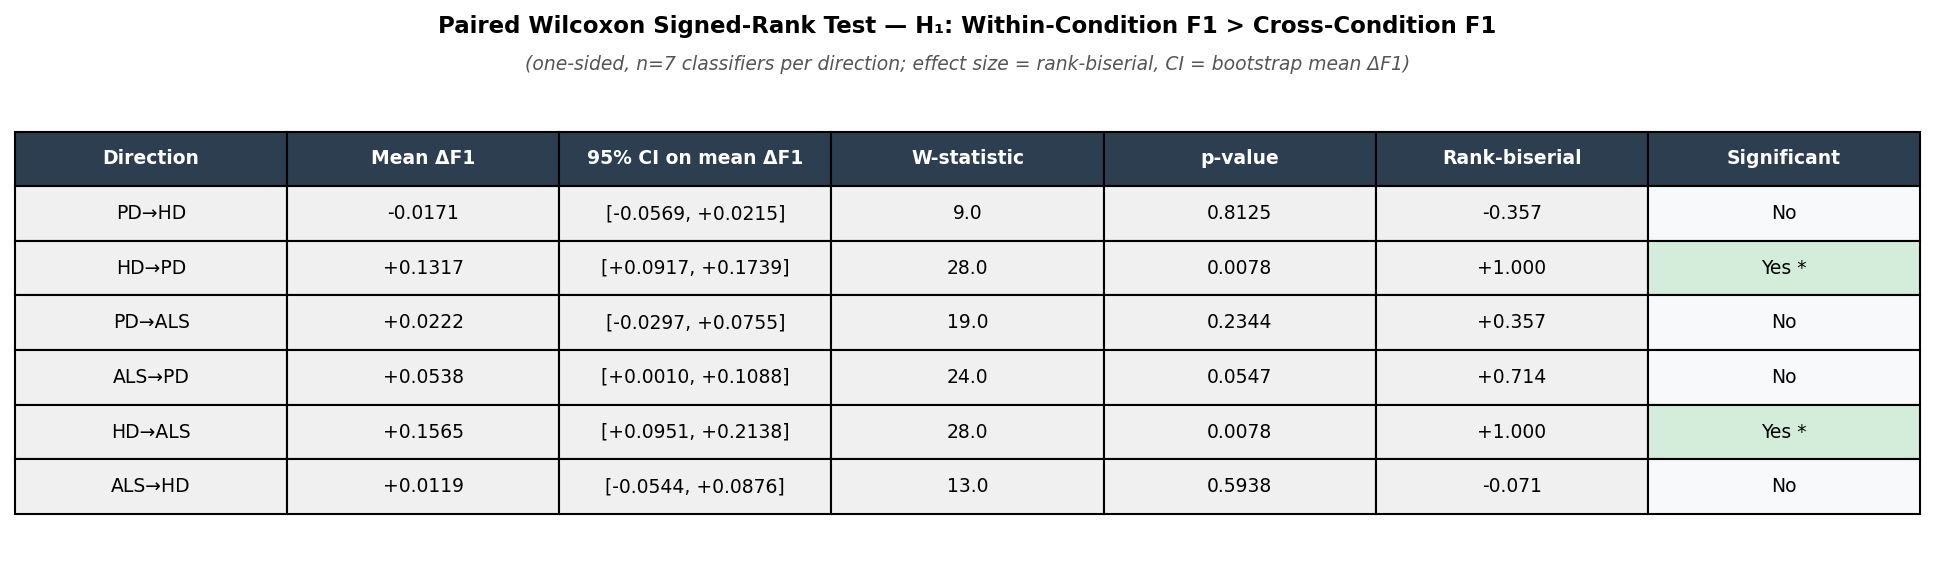

Saved: wilcoxon_test.pdf / .png


In [ ]:
from scipy import stats
from IPython.display import display

def rank_biserial_from_diff(diff: np.ndarray) -> float:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.abs(diff) > 0]
    if len(diff) == 0:
        return float('nan')
    ranks = stats.rankdata(np.abs(diff))
    w_pos = float(ranks[diff > 0].sum())
    w_neg = float(ranks[diff < 0].sum())
    total = len(diff) * (len(diff) + 1) / 2
    return (w_pos - w_neg) / total

def bootstrap_mean_ci(diff: np.ndarray, rng: np.random.Generator, n_boot: int = 10000) -> tuple[float, float]:
    diff = np.asarray(diff, dtype=float)
    n = len(diff)
    boot = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[i] = diff[idx].mean()
    return tuple(np.percentile(boot, [2.5, 97.5]))

rng = np.random.default_rng(42)
wilcoxon_rows = []
for direction, dir_label in zip(DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    within_vals = np.array([WITHIN_F1_PER_CLF[src][clf] for clf in CLF_NAMES], dtype=float)
    cross_vals = np.array([cc[direction]['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES], dtype=float)
    diff = within_vals - cross_vals

    if np.all(diff == 0):
        stat, p = float('nan'), float('nan')
        effect = float('nan')
    else:
        stat, p = stats.wilcoxon(diff, alternative='greater', zero_method='wilcox')
        effect = rank_biserial_from_diff(diff)

    ci_lower, ci_upper = bootstrap_mean_ci(diff, rng)
    wilcoxon_rows.append({
        'direction': dir_label,
        'mean_delta': float(diff.mean()),
        'delta_ci_lower': float(ci_lower),
        'delta_ci_upper': float(ci_upper),
        'w_statistic': float(stat),
        'p_value': float(p),
        'rank_biserial': float(effect),
        'significant': bool(p < 0.05),
    })

df_wilcoxon = pd.DataFrame(wilcoxon_rows)
df_wilcoxon['delta_ci'] = df_wilcoxon.apply(
    lambda r: f"[{r['delta_ci_lower']:+.4f}, {r['delta_ci_upper']:+.4f}]",
    axis=1,
)
display_cols = ['direction', 'mean_delta', 'delta_ci', 'w_statistic', 'p_value', 'rank_biserial', 'significant']

styled_wilcoxon = (
    df_wilcoxon[display_cols].style
    .format({
        'mean_delta': '{:+.4f}',
        'w_statistic': '{:.1f}',
        'p_value': '{:.4f}',
        'rank_biserial': '{:+.3f}',
    })
    .applymap(
        lambda v: 'background-color: #d4edda; color: #155724' if v else 'background-color: #f8f9fa; color: #6c757d',
        subset=['significant']
    )
    .set_caption(
        'Paired Wilcoxon Signed-Rank Test: H₁ = Within-Condition F1 > Cross-Condition F1\n'
        '(one-sided, n=7 classifiers per direction; includes rank-biserial effect size and bootstrap mean-ΔF1 CI)'
    )
)
display(styled_wilcoxon)

fig_w, ax_w = plt.subplots(figsize=(13, 3.8))
ax_w.axis('off')

col_labels_w = ['Direction', 'Mean ΔF1', '95% CI on mean ΔF1', 'W-statistic', 'p-value', 'Rank-biserial', 'Significant']
table_data_w = []
cell_colors_w = []

for _, row in df_wilcoxon.iterrows():
    sig_text = 'Yes ***' if row['p_value'] < 0.001 else ('Yes *' if row['p_value'] < 0.05 else 'No')
    table_data_w.append([
        row['direction'],
        f"{row['mean_delta']:+.4f}",
        row['delta_ci'],
        f"{row['w_statistic']:.1f}",
        f"{row['p_value']:.4f}",
        f"{row['rank_biserial']:+.3f}",
        sig_text,
    ])
    sig_color = '#d4edda' if row['significant'] else '#f8f9fa'
    cell_colors_w.append(['#f0f0f0', '#f0f0f0', '#f0f0f0', '#f0f0f0', '#f0f0f0', '#f0f0f0', sig_color])

tbl_w = ax_w.table(
    cellText=table_data_w,
    colLabels=col_labels_w,
    cellColours=cell_colors_w,
    loc='center',
    cellLoc='center',
)
tbl_w.auto_set_font_size(False)
tbl_w.set_fontsize(9)
tbl_w.scale(1, 2.1)

for j in range(len(col_labels_w)):
    tbl_w[0, j].set_facecolor('#2c3e50')
    tbl_w[0, j].get_text().set_color('white')
    tbl_w[0, j].get_text().set_fontweight('bold')

fig_w.text(0.5, 0.98, 'Paired Wilcoxon Signed-Rank Test — H₁: Within-Condition F1 > Cross-Condition F1', ha='center', va='top', fontsize=11, fontweight='bold')
fig_w.text(0.5, 0.91, '(one-sided, n=7 classifiers per direction; effect size = rank-biserial, CI = bootstrap mean ΔF1)', ha='center', va='top', fontsize=9, style='italic', color='#555555')
fig_w.tight_layout(rect=[0, 0, 1, 0.88])
fig_w.savefig(FIGURES_PDF / 'wilcoxon_test.pdf')
fig_w.savefig(FIGURES_PNG / 'wilcoxon_test.png')
plt.show()
plt.close(fig_w)
print('Saved: wilcoxon_test.pdf / .png')


## Results Narrative

The authoritative v2 transfer results should be read direction-by-direction rather than source-averaged. `PD→HD` remains the strongest raw transfer surface on average, while `HD→ALS` carries the largest degradation burden when each classifier is compared against its own within-condition baseline.

The figures in this notebook therefore support three core claims for the paper:

1. Cross-condition transfer is asymmetric.
2. Raw cross-condition F1 and ΔF1 tell complementary stories.
3. Subject-level accuracy, recall balance, and CI width add important context beyond a single aggregate F1 score.

Those are the authoritative v2 results that the SHAP notebook should interpret mechanistically in Step 4.
